# Антибот: поиск ботов по событиям суточного окна (v3)

Задача - по событиям cookie за сутки оценить вероятность, что это трафик сервиса сбора данных.
Метрика - Precision при Recall >= 0.7.

| версия | что внутри | P@R, forward-CV | P@R, leave-2-days-out | PR-AUC |
|---|---|---|---|---|
| baseline из quickstart | RandomForest на 2 признаках | 0.10 | 0.10 | 0.21 |
| v1 | 77 поведенческих признаков, 2 LightGBM | 0.77 | 0.79 | 0.80 |
| v2 | + курсор, сессии, модель на уровне событий, ансамбль из 5 моделей | 0.78 | 0.83 | 0.81 |
| v3 (этот ноутбук) | + связи кук через общие объявления, ансамбль перенастроен | 0.87 | 0.88 | 0.83 |

v2 и v3 посчитаны в одном цикле CV с 3 сидами (раздел 9), цифры v1 и baseline взяты из ноутбука v2 (`v2/solution_v2.ipynb`).
На платформе v3 получила P@R 0.8997.
При том же recall 0.7 v3 ошибочно отмечает на треть меньше людей, чем v2 (87 против 130).

Что нового в v3. В v2 каждая кука рассматривалась отдельно. Но боты одного сервиса обходят один и тот же
каталог объявлений, поэтому их куки пересекаются по открытым объявлениям между собой и с ботами прошлых дней.
v3 добавляет два блока признаков связей:

- без меток: популярность объявлений куки среди других кук и поведение кук-соседей по общим объявлениям;
- с метками: насколько объявления и соседи куки пересекаются с известными ботами прошлых дней. Эти признаки
  строятся внутри каждого фолда только по меткам обучающей части.

Поведенческая база v2 (77 признаков, курсор, сессии, модель на уровне событий) перенесена без изменений.

Содержание:
1. Данные
2. Качество событий и очистка
3. Исследование данных
4. Признаки куки (v1)
5. Признаки v2: курсор и сессии
6. Модель на уровне событий
7. Новые признаки v3: связи кук через объявления
8. Валидация
9. Модели и сравнение версий
10. Финальная модель и сабмит
11. Что пробовали в v3
12. Выводы и ограничения

In [1]:
import warnings
warnings.filterwarnings('ignore')
import gc
import time

import numpy as np
import pandas as pd
import scipy.sparse as sp
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score, average_precision_score

from metric import precision_at_recall   # официальная реализация метрики из архива (ей же считает проверка)

SEED = 42
RUN_CV = True           # False - пропустить кросс-валидацию и сразу обучить финал (~5 минут)
N_JOBS = 2
np.random.seed(SEED)
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)
T0 = time.time()

## 1. Данные

In [2]:
DATES = ['cookie_created_at', 'window_start_ts', 'window_end_ts']
train = pd.read_csv('data/train.csv', parse_dates=DATES)
test = pd.read_csv('data/test.csv', parse_dates=DATES)
events = pd.read_csv('data/events.csv.gz', parse_dates=['event_ts'])
meta = pd.concat([train, test], ignore_index=True)

print('train', train.shape, 'test', test.shape, 'events', events.shape)
print('доля ботов в train:', round(train.target.mean(), 4))
print('окна train:', train.window_start_ts.min().date(), '-', train.window_start_ts.max().date())
print('окна test: ', test.window_start_ts.min().date(), '-', test.window_start_ts.max().date())
print('дубли cookie_id: train', train.cookie_id.duplicated().sum(), 'test', test.cookie_id.duplicated().sum(),
      '| пересечение train/test:', len(set(train.cookie_id) & set(test.cookie_id)))

train (11091, 5) test (4909, 4) events (328905, 14)
доля ботов в train: 0.0811
окна train: 2026-04-06 - 2026-04-19
окна test:  2026-04-20 - 2026-04-26
дубли cookie_id: train 0 test 0 | пересечение train/test: 0


## 2. Качество событий и очистка

Сначала проверяем то, что может сломать признаки: события вне окна, порядок строк, дубли, пропуски.

In [3]:
e = events.merge(meta[['cookie_id', 'window_start_ts', 'window_end_ts', 'target']], on='cookie_id')
e['pos'] = np.select([e.event_ts < e.window_start_ts, e.event_ts >= e.window_end_ts], ['до окна', 'после окна'], 'в окне')

print('Файл отсортирован по времени?', events.event_ts.is_monotonic_increasing)
print('Точных дублей строк:', events.duplicated().sum())
print('\nПоложение событий относительно окна:')
print(e.pos.value_counts(normalize=True).round(3))
print('\nТипы событий: в окне vs после окна')
print(pd.crosstab(e.event_name, e.pos))

Файл отсортирован по времени? False


Точных дублей строк: 4863

Положение событий относительно окна:
pos
в окне        0.876
после окна    0.124
Name: proportion, dtype: float64

Типы событий: в окне vs после окна
pos                   в окне  после окна
event_name                              
captcha_shown              0        7928
contact_chat_open       5548         577
contact_message_sent    2823         258
contact_phone_show     10288        1028
favorite_add           17296        1753
item_view             108086       12731
login                   5661         606
photo_swipe            33084        3433
search_results_view    89798       10604
seller_page_view       15542        1861


Все `captcha_shown` лежат после окна. Капча - реакция антибота, то есть следствие разметки, поэтому
любые события после `window_end_ts` использовать нельзя. К тому же у ботов после окна 42% событий, у людей 11%:
даже простой счётчик событий без фильтра был бы утечкой.

In [4]:
print('Доля событий внутри окна по классам (train):')
print(e[e.target.notna()].groupby('target').pos.apply(lambda s: (s == 'в окне').mean()).round(3))
print('\nplatform как есть:')
print(events.platform.value_counts())
print('\nПропуски:')
print(events.isna().mean().round(3).to_string())

Доля событий внутри окна по классам (train):


target
0.0    0.890
1.0    0.575
Name: pos, dtype: float64

platform как есть:
platform
desktop    46866
WEB        46476
Web        46365
web        45951
ANDROID    42462
Android    42254
android    42159
iphone      4103
IOS         4100
iOS         4091
ios         4078
Name: count, dtype: int64

Пропуски:


cookie_id        0.000
event_ts         0.000
eid              0.000
event_name       0.000
platform         0.000
user_agent       0.000
item_id          0.348
item_category    0.100
item_location    0.072
seller_type      0.407
search_query     0.695
search_page      0.695
pointer_x        0.670
pointer_y        0.670


Пропуски структурные: запрос и страница есть только у просмотра выдачи, курсор - только на desktop,
поля объявления - только у событий с объявлением. Поэтому пропуски не заполняем: признак считается по событиям,
где поле есть, а если таких нет, остаётся `NaN`. Бустинги обрабатывают это сами.

Очистка: оставляем события строго внутри окна, сортируем по времени (файл перемешан), удаляем точные дубли,
приводим `platform` к трём значениям, `user_agent` сводим к классу клиента.

In [5]:
PLATFORM_MAP = {'desktop': 'desktop', 'web': 'desktop', 'android': 'android', 'ios': 'ios', 'iphone': 'ios'}


def clean_events(events, meta):
    # точные дубли - артефакт логирования (одинаковая доля у ботов и людей)
    ev = events.drop_duplicates()
    ev = ev.merge(meta[['cookie_id', 'window_start_ts', 'window_end_ts']], on='cookie_id')
    # строго [start, end): признаки должны быть доступны на момент окончания окна
    ev = ev[(ev.event_ts >= ev.window_start_ts) & (ev.event_ts < ev.window_end_ts)].copy()
    ev['platform'] = ev.platform.str.lower().map(PLATFORM_MAP)
    # UA -> класс клиента (версии браузера/приложения - шум)
    ua = ev.user_agent
    ev['ua_class'] = np.select(
        [ua.str.contains('HeadlessChrome'),
         ~ua.str.startswith(('Mozilla', 'Avito/')),      # python-requests, curl, Scrapy, Go-http-client...
         ua.str.startswith('Avito/')],
        ['headless', 'http_lib', 'app'], 'browser')
    # файл перемешан: сортируем внутри куки по времени (eid - стабильный tie-break)
    return ev.sort_values(['cookie_id', 'event_ts', 'eid'], kind='mergesort').reset_index(drop=True)


ev = clean_events(events, meta)
assert ev.event_name.ne('captcha_shown').all()
print('событий после очистки:', len(ev), '| кук с событиями:', ev.cookie_id.nunique(), 'из', len(meta))
print(ev.platform.value_counts().to_string())
print(pd.crosstab(ev.merge(train[['cookie_id', 'target']]).ua_class,
                  ev.merge(train[['cookie_id', 'target']]).target, normalize='index').round(3))

событий после очистки: 283833 | кук с событиями: 16000 из 16000
platform
desktop    158898
android    110556
ios         14379


target        0      1
ua_class              
app       0.880  0.120
browser   0.888  0.112
headless  0.500  0.500
http_lib  0.581  0.419


## 3. Исследование данных

Смотрим на поведение ботов и людей по train. Всё ниже посчитано по очищенным событиям внутри окна.

In [6]:
# общий стиль графиков: человек - синий, бот - оранжевый
COL = {0: '#2a78d6', 1: '#eb6834'}
LBL = {0: 'человек', 1: 'бот'}
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.alpha': 0.25, 'axes.titlesize': 11, 'axes.titleweight': 'bold',
                     'legend.frameon': False})

et = ev.merge(train[['cookie_id', 'target']], on='cookie_id')
et['dt'] = et.groupby('cookie_id').event_ts.diff().dt.total_seconds()

# одна строка на куку - для графиков по кукам
ck = train[['cookie_id', 'target', 'cookie_created_at', 'window_start_ts']].merge(
    et.groupby('cookie_id').agg(n_events=('eid', 'size'),
                                platform=('platform', lambda s: s.mode().iloc[0]),
                                ua_class=('ua_class', lambda s: s.mode().iloc[0]),
                                n_loc=('item_location', 'nunique'),
                                n_cat=('item_category', 'nunique'),
                                page_max=('search_page', 'max')).reset_index(), on='cookie_id')
ck['age_h'] = (ck.window_start_ts - ck.cookie_created_at).dt.total_seconds() / 3600 + 24   # возраст на конец окна, часов


def hist_by_class(ax, col, data, bins, title, xlabel, logx=False):
    for t in (0, 1):
        v = data.loc[data.target == t, col].dropna()
        ax.hist(v, bins=bins, weights=np.full(len(v), 1 / len(v)), histtype='step', lw=2, color=COL[t], label=LBL[t])
    ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel('доля кук')
    if logx:
        ax.set_xscale('log')
    ax.legend()

### Время и баланс классов

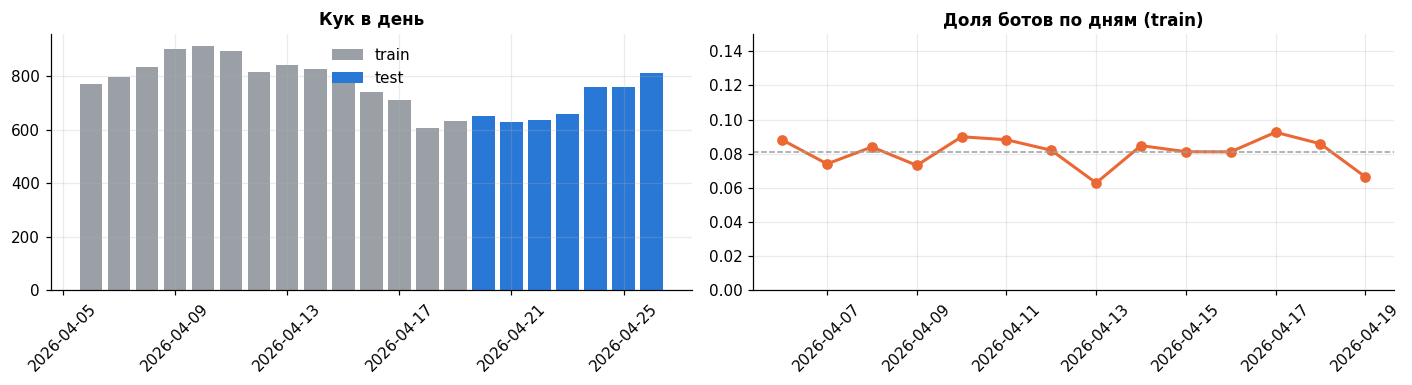

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
n_tr = train.groupby(train.window_start_ts.dt.date).size()
n_te = test.groupby(test.window_start_ts.dt.date).size()
ax[0].bar(n_tr.index, n_tr.values, color='#9aa0a6', label='train')
ax[0].bar(n_te.index, n_te.values, color='#2a78d6', label='test')
ax[0].set_title('Кук в день'); ax[0].legend(); ax[0].tick_params(axis='x', rotation=45)
share = train.groupby(train.window_start_ts.dt.date).target.mean()
ax[1].plot(share.index, share.values, marker='o', lw=2, color=COL[1])
ax[1].axhline(train.target.mean(), ls='--', color='#9aa0a6', lw=1)
ax[1].set_ylim(0, 0.15); ax[1].set_title('Доля ботов по дням (train)'); ax[1].tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

Test идёт сразу после train, без пересечения по дням. Доля ботов по дням стабильна: 6-9%, в среднем 8%.
Поэтому валидация строится по времени, а метрика будет шумной: в тестовой неделе около 400 ботов.

### Объём и состав активности

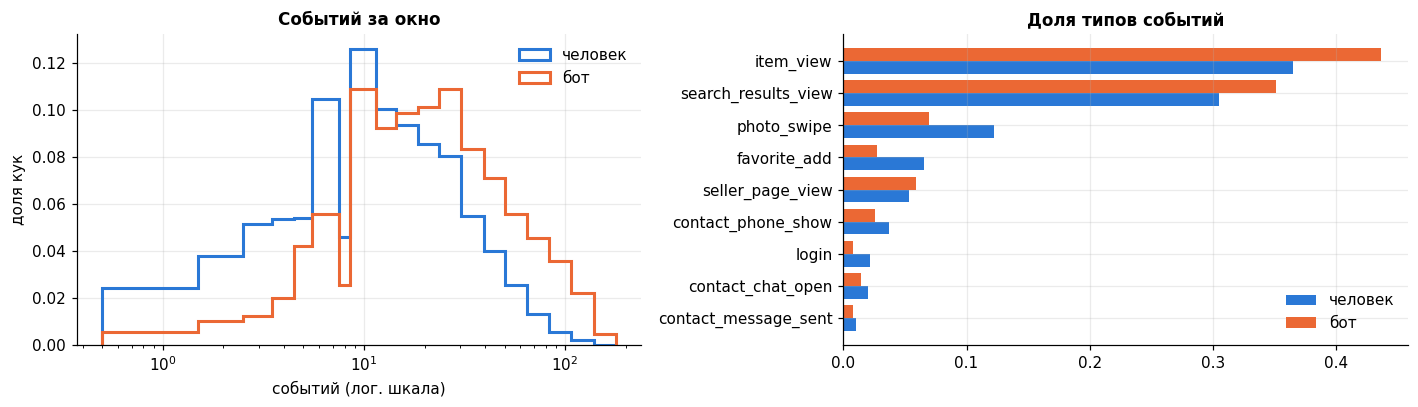

медиана событий: люди 12.0 | боты 20.0
медиана городов: люди 5.0 | боты 8.0 | медиана дальней страницы: люди 4.0 | боты 7.0


In [8]:
fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
edges = np.r_[0.5, np.unique(np.round(np.logspace(0.15, 2.25, 20))) + 0.5]   # целые границы на лог. шкале
hist_by_class(ax[0], 'n_events', ck, edges, 'Событий за окно', 'событий (лог. шкала)', logx=True)
comp = pd.crosstab(et.event_name, et.target, normalize='columns')
comp = comp.loc[comp[0].sort_values().index]
y_ = np.arange(len(comp))
ax[1].barh(y_ - 0.2, comp[0], height=0.4, color=COL[0], label=LBL[0])
ax[1].barh(y_ + 0.2, comp[1], height=0.4, color=COL[1], label=LBL[1])
ax[1].set_yticks(y_, comp.index); ax[1].set_title('Доля типов событий'); ax[1].legend()
plt.tight_layout(); plt.show()
print('медиана событий: люди', ck[ck.target == 0].n_events.median(), '| боты', ck[ck.target == 1].n_events.median())
print('медиана городов: люди', ck[ck.target == 0].n_loc.median(), '| боты', ck[ck.target == 1].n_loc.median(),
      '| медиана дальней страницы: люди', ck[ck.target == 0].page_max.median(), '| боты', ck[ck.target == 1].page_max.median())

У ботов событий больше (медиана 20 против 12), и почти все они - просмотры выдачи и объявлений.
Избранное, фото, контакты и логин у них встречаются в 1.5-2.5 раза реже. Отсюда признаки состава событий
и вовлечённости. Но распределения сильно пересекаются: по одному объёму ботов не отделить.

### Ритм событий

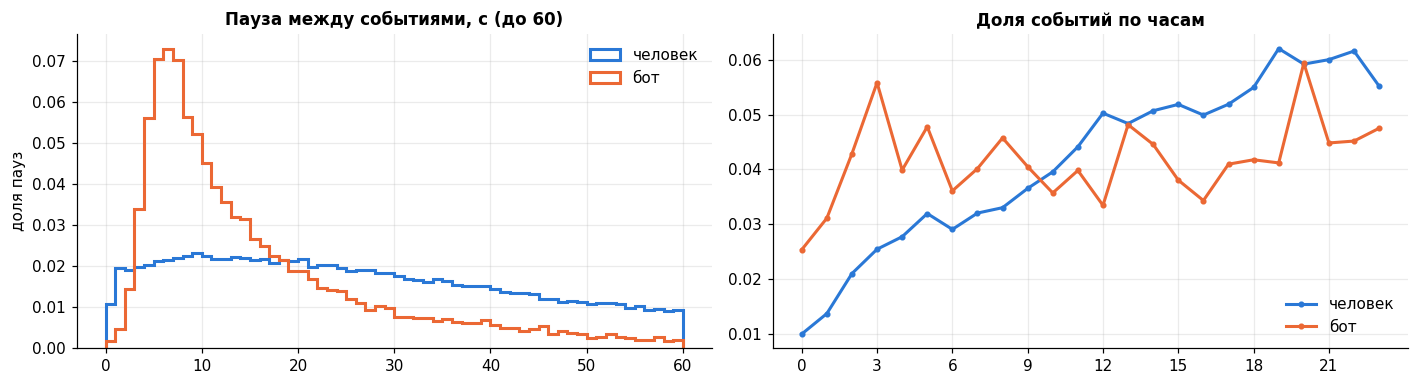

доля пауз, равных предыдущей: люди 0.019 | боты 0.084


In [9]:
fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
d = et[et.dt < 60]
for t in (0, 1):
    v = d.dt[d.target == t]
    ax[0].hist(v, bins=np.arange(0, 61), weights=np.full(len(v), 1 / len(v)), histtype='step', lw=2, color=COL[t], label=LBL[t])
ax[0].set_title('Пауза между событиями, с (до 60)'); ax[0].set_ylabel('доля пауз'); ax[0].legend()
hr = pd.crosstab(et.event_ts.dt.hour, et.target, normalize='columns')
for t in (0, 1):
    ax[1].plot(hr.index, hr[t], lw=2, marker='o', ms=3, color=COL[t], label=LBL[t])
ax[1].set_title('Доля событий по часам'); ax[1].set_xticks(range(0, 24, 3)); ax[1].legend()
plt.tight_layout(); plt.show()
same = et.assign(prev=et.groupby('cookie_id').dt.shift()).query('dt < 60 and prev < 60')
print('доля пауз, равных предыдущей: люди', round((same[same.target == 0].dt == same[same.target == 0].prev).mean(), 3),
      '| боты', round((same[same.target == 1].dt == same[same.target == 1].prev).mean(), 3))

Самый сильный сигнал. У ботов паузы собраны в пик 3-10 секунд, как задержка в скрипте, у людей распределение
почти равномерное. Одну и ту же паузу подряд боты повторяют в 4 раза чаще (8.4% против 1.9%). По часам люди
активны к вечеру, а боты работают ровнее: ночью (0-6 ч) у них 24% событий против 13% у людей.

### Курсор (только desktop)

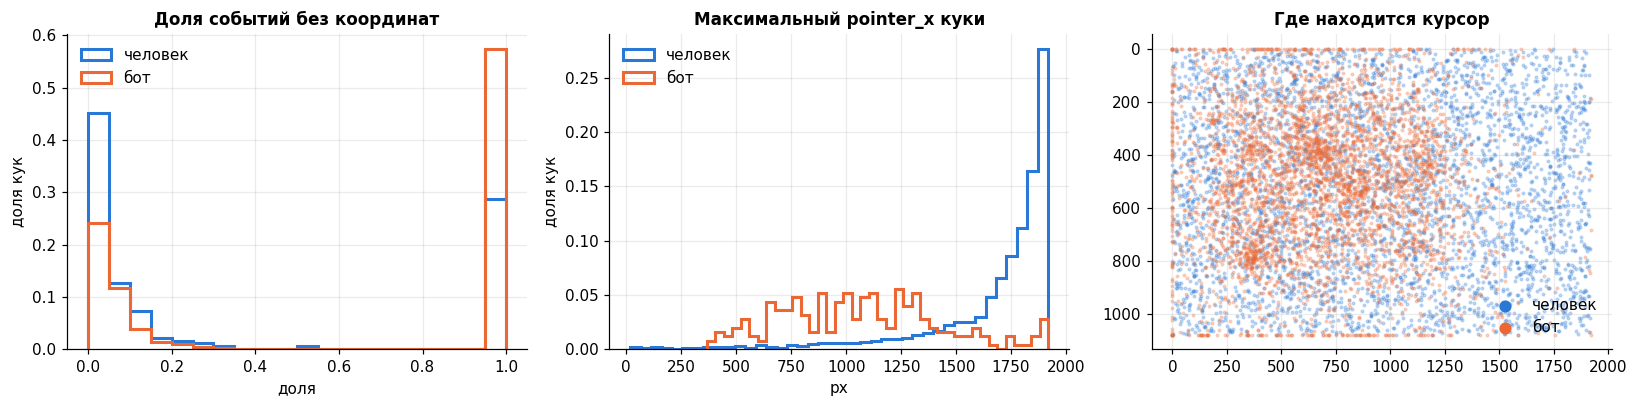

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
dk = et[et.platform == 'desktop']
miss = dk.groupby('cookie_id').agg(target=('target', 'first'), miss=('pointer_x', lambda s: s.isna().mean()))
hist_by_class(ax[0], 'miss', miss, np.linspace(0, 1, 21), 'Доля событий без координат', 'доля')
xmax = dk.dropna(subset=['pointer_x']).groupby('cookie_id').agg(target=('target', 'first'), xmax=('pointer_x', 'max'))
hist_by_class(ax[1], 'xmax', xmax, 40, 'Максимальный pointer_x куки', 'px')
pts = dk.dropna(subset=['pointer_x'])
for t in (0, 1):
    s = pts[pts.target == t].sample(min(4000, (pts.target == t).sum()), random_state=0)
    ax[2].scatter(s.pointer_x, s.pointer_y, s=3, alpha=0.25, color=COL[t], label=LBL[t])
ax[2].invert_yaxis(); ax[2].set_title('Где находится курсор')
leg = ax[2].legend(markerscale=4, loc='lower right')
for h in leg.legend_handles:
    h.set_alpha(1)
plt.tight_layout(); plt.show()

Здесь сразу несколько сигналов. У 57% desktop-кук ботов нет координат ни в одном событии, у людей таких 29%.
Если координаты есть, курсор бота почти не заходит правее 1000-1300 px: похоже на маленький виртуальный экран.
Люди доходят до 1920 px и покрывают весь экран, а у ботов точки собраны в нескольких зонах.
Отсюда признаки пропусков, разброса, максимума и траектории курсора.

### Что и как смотрят

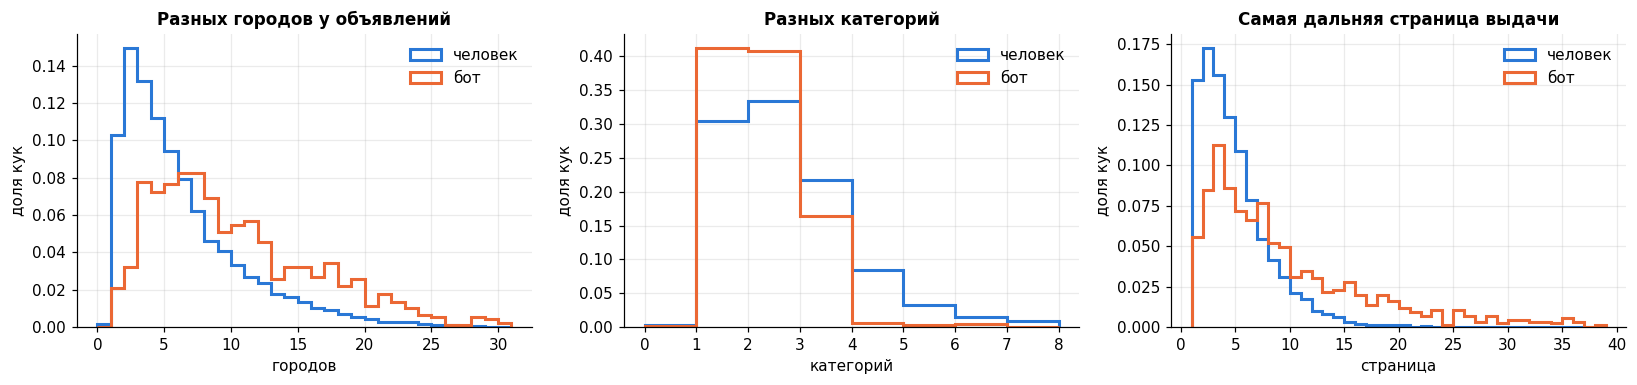

In [11]:
fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
hist_by_class(ax[0], 'n_loc', ck, np.arange(0, 32, 1), 'Разных городов у объявлений', 'городов')
hist_by_class(ax[1], 'n_cat', ck, np.arange(0, 9, 1), 'Разных категорий', 'категорий')
hist_by_class(ax[2], 'page_max', ck, np.arange(1, 40, 1), 'Самая дальняя страница выдачи', 'страница')
plt.tight_layout(); plt.show()

Боты смотрят объявления из многих городов (медиана 8 против 5), но почти всегда в 1-3 категориях. Похоже на сбор
цен по региональным выдачам. По выдаче они уходят дальше: медиана самой дальней страницы 7 против 4.
При этом конкретные запросы, города и категории ботов не выдают: доля ботов по ним в пределах случайного разброса.

### Платформа, User-Agent и возраст куки

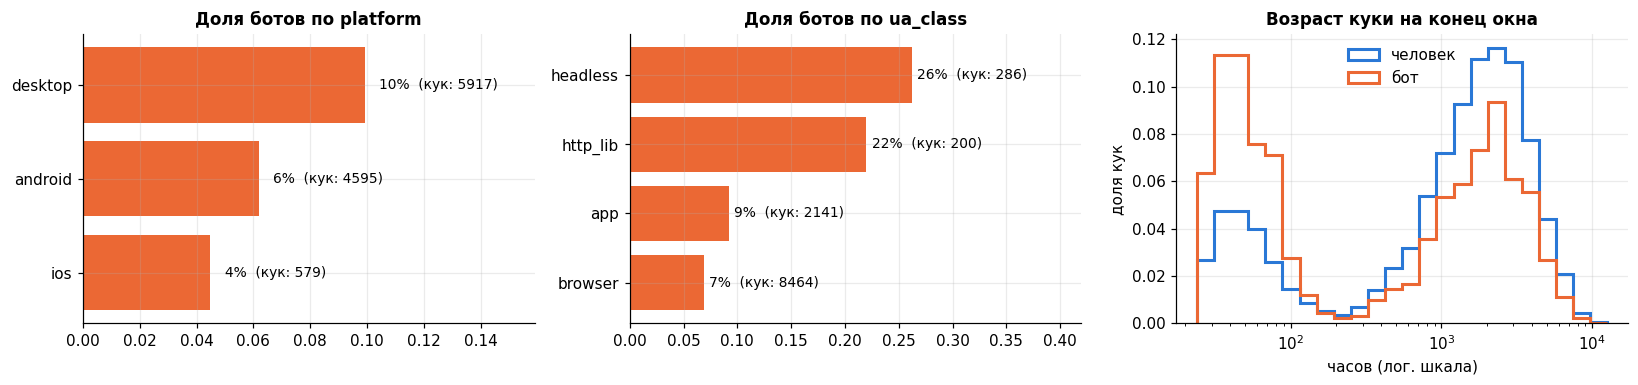

ботов среди кук с обычным браузером или приложением: 0.87


In [12]:
fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
for i, col in enumerate(['platform', 'ua_class']):
    r = ck.groupby(col).target.agg(['mean', 'size']).sort_values('mean')
    ax[i].barh(r.index, r['mean'], color=COL[1])
    for j, (m, n) in enumerate(zip(r['mean'], r['size'])):
        ax[i].text(m + 0.005, j, f'{m:.0%}  (кук: {n})', va='center', fontsize=9)
    ax[i].set_xlim(0, max(r['mean']) * 1.6); ax[i].set_title(f'Доля ботов по {col}')
hist_by_class(ax[2], 'age_h', ck, np.logspace(np.log10(24), 4.1, 25), 'Возраст куки на конец окна', 'часов (лог. шкала)', logx=True)
plt.tight_layout(); plt.show()
print('ботов среди кук с обычным браузером или приложением:', round(ck[ck.ua_class.isin(['browser', 'app'])].target.sum() / ck.target.sum(), 2))

Среди headless-браузеров и HTTP-библиотек ботов 22-26%, втрое больше среднего, но таких кук всего 4%.
87% ботов приходят с обычным браузером или приложением, поэтому User-Agent - вспомогательный признак.
На мобильных платформах ботов меньше (4-6%) и у них нет курсора: это самый трудный сегмент.
Куки ботов моложе: медиана возраста 20 дней против 63, каждая четвёртая создана меньше чем за 2 дня до конца окна.

### Связи кук через общие объявления

Каталог Авито огромен, а за две недели куки открыли около 53 тысяч разных объявлений. Если две случайные
куки открыли одно и то же объявление, это редкость. Боты одного сервиса обходят общий список объявлений,
поэтому у них пересечений должно быть больше. Проверяем два вопроса:

- насколько популярны объявления куки среди других кук (без меток);
- какая доля объявлений куки уже открывалась известными ботами строго более ранних дней.

Второе считаем только для окон с 10 апреля, когда накоплено хотя бы 4 дня истории.

объявлений, открытых хотя бы одним известным ботом раньше (окна с 10 апреля), средняя доля по кукам:
target
человек    0.090
бот        0.474

медианы по кукам с объявлениями:


,n_items,others_mean,solo_share
target,,,
человек,6.0,0.935,0.417
бот,10.0,1.500,0.250


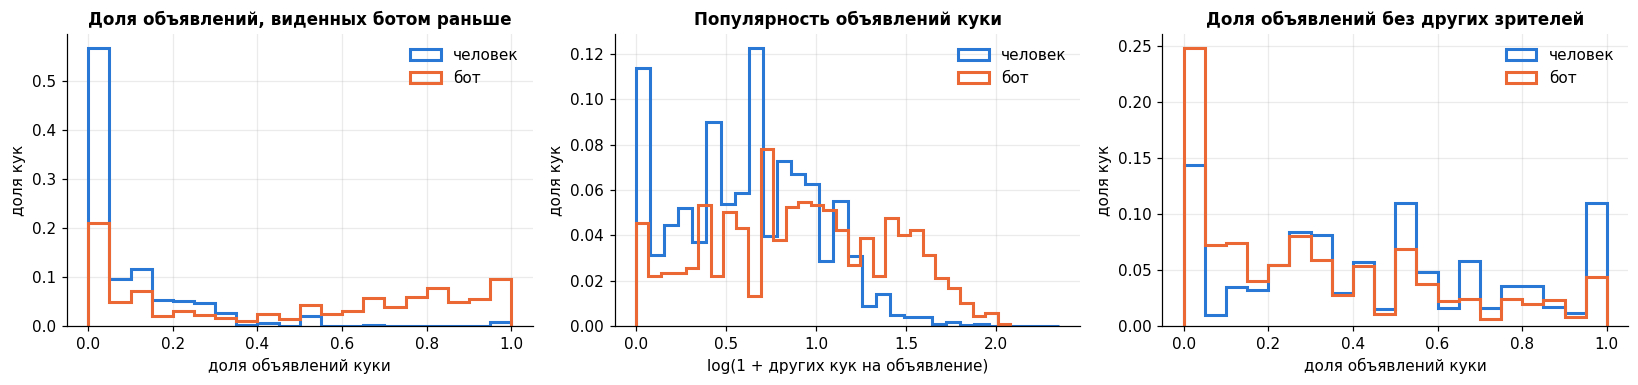

In [13]:
# пары (кука, объявление) без повторов и номер дня окна; компактные типы - int32/int16
day_of = ((meta.set_index('cookie_id').window_start_ts - meta.window_start_ts.min()) // pd.Timedelta(days=1)).astype('int16')
iv = ev.loc[ev.item_id.notna(), ['cookie_id', 'item_id']].drop_duplicates()
iv['item_id'] = iv.item_id.astype('int32')
iv['day'] = iv.cookie_id.map(day_of).astype('int16')

# сколько кук открывали объявление в тот же или более ранний день (все куки, метки не нужны), минус сама кука
per_day = iv.groupby(['item_id', 'day']).size().rename('n').reset_index().sort_values(['item_id', 'day'])
per_day['cum'] = per_day.groupby('item_id').n.cumsum().astype('int32')
iv = iv.merge(per_day[['item_id', 'day', 'cum']], on=['item_id', 'day'], how='left')
iv['others'] = iv.cum - 1

# первый день, когда объявление открыл бот из train; сравнение строгое - только прошлые дни
ivt = iv.merge(train[['cookie_id', 'target']], on='cookie_id')
first_bot_day = ivt[ivt.target == 1].groupby('item_id').day.min()
ivt['bot_before'] = ivt.item_id.map(first_bot_day).lt(ivt.day)

lk = ivt.groupby('cookie_id').agg(target=('target', 'first'), day=('day', 'first'), n_items=('item_id', 'size'),
                                  others_mean=('others', 'mean'), solo_share=('others', lambda s: (s == 0).mean()),
                                  bot_before_share=('bot_before', 'mean'))
late = lk[lk.day >= 4]
print('объявлений, открытых хотя бы одним известным ботом раньше (окна с 10 апреля), средняя доля по кукам:')
print(late.groupby('target').bot_before_share.mean().rename(index=LBL).round(3).to_string())
print('\nмедианы по кукам с объявлениями:')
display(lk.groupby('target')[['n_items', 'others_mean', 'solo_share']].median().rename(index=LBL).round(3))

fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
hist_by_class(ax[0], 'bot_before_share', late, np.linspace(0, 1, 21), 'Доля объявлений, виденных ботом раньше', 'доля объявлений куки')
lk['others_log'] = np.log1p(lk.others_mean)
hist_by_class(ax[1], 'others_log', lk, 30, 'Популярность объявлений куки', 'log(1 + других кук на объявление)')
hist_by_class(ax[2], 'solo_share', lk, np.linspace(0, 1, 21), 'Доля объявлений без других зрителей', 'доля объявлений куки')
plt.tight_layout(); plt.show()
del iv, ivt, per_day
_ = gc.collect()

Сигнал сильный. В окнах с 10 апреля в среднем 47% объявлений бота уже открывал какой-то бот прошлых дней,
у людей - 9%. У 57% людей таких объявлений нет вовсе, у ботов - только у 21%. Без меток видно то же самое:
объявления ботов популярнее среди других кук (в среднем 1.5 другой куки на объявление против 0.9), а объявлений,
которые больше никто не открывал, у ботов меньше (25% против 42%).

Сами объявления, города и категории ботов не выдают (раздел выше), выдают пересечения: боты разных кук
ходят по одним и тем же объявлениям. В v2 проверялась похожесть на известных ботов по поведению (kNN), и она
не дала прироста. Похожесть по списку объявлений - другой, независимый от поведения сигнал.

### Выводы из EDA

- Валидация только по времени. Сдвига между неделями не видно, доля ботов стабильна.
- Главные сигналы поведенческие: ритм событий, курсор, обход городов и глубина выдачи. Под них строятся признаки.
- Контент (запросы, города, категории) и User-Agent сами по себе слабые, их используем только как
  вспомогательные признаки.
- Мобильные боты - слабое место: курсора нет, событий меньше. Здесь нужен сигнал из последовательности событий,
  отсюда модель на уровне событий в v2.
- Новое в v3: сами объявления нейтральны, но пересечение объявлений с другими куками и особенно с известными
  ботами прошлых дней - сильный сигнал. Он не зависит от платформы, поэтому должен помочь и на мобильных.

## 4. Признаки куки (v1)

77 признаков по событиям окна, без таргета: тайминг, состав событий и переходы, разнообразие контента,
пагинация, курсор, клиент, возраст куки. `item_pop_*` используют события других кук того же дня -
это известно на конец окна и не использует разметку.

In [14]:
EVENTS = ['search_results_view', 'item_view', 'photo_swipe', 'seller_page_view', 'favorite_add',
          'contact_phone_show', 'contact_chat_open', 'contact_message_sent', 'login']
CONTACT = ['contact_phone_show', 'contact_chat_open', 'contact_message_sent']
SCRAPE_EVENTS = {'search_results_view', 'item_view', 'seller_page_view'}


def entropy(s):
    p = s.value_counts(normalize=True).values
    return float(-(p * np.log(p)).sum()) if len(p) else 0.0


def by_cookie(values, cookie):
    # короткий помощник: группировка произвольного Series по cookie_id
    return values.groupby(cookie)


def build_features(ev, meta):
    ev = ev.copy()
    g = ev.groupby('cookie_id', sort=False)
    ck = ev.cookie_id
    ev['dt'] = g.event_ts.diff().dt.total_seconds()        # интервал до предыдущего события куки
    f = pd.DataFrame(index=pd.Index(meta.cookie_id, name='cookie_id'))

    # --- 1. Тайминг
    dtg = ev.dropna(subset=['dt']).groupby('cookie_id').dt
    f['dt_min'], f['dt_median'], f['dt_mean'], f['dt_std'] = dtg.min(), dtg.median(), dtg.mean(), dtg.std()
    f['dt_cv'] = f.dt_std / (f.dt_mean + 1e-9)
    f['dt_q10'], f['dt_q90'] = dtg.quantile(0.1), dtg.quantile(0.9)
    has_dt = ev.dt.notna()
    for name, cond in [('dt_3_10', ev.dt.between(3, 10)), ('dt_le1', ev.dt <= 1), ('dt_gt300', ev.dt > 300)]:
        f[f'share_{name}'] = cond[has_dt].groupby(ck[has_dt]).mean()
    short = ev.dt[ev.dt < 60]                                  # темп внутри активности, без долгих пауз
    sg = short.groupby(ck[short.index])
    f['dt_short_median'], f['dt_short_std'] = sg.median(), sg.std()
    f['dt_short_cv'] = f.dt_short_std / (sg.mean() + 1e-9)
    f['dt_short_mad'] = sg.agg(lambda s: np.median(np.abs(s - np.median(s))))
    span = (g.event_ts.max() - g.event_ts.min()).dt.total_seconds()
    f['span_h'] = span / 3600
    f['n_events'] = g.size()
    f['events_per_min_active'] = f.n_events / (span / 60 + 1)
    f['max_events_5min'] = ev.groupby(['cookie_id', ev.event_ts.dt.floor('5min')]).size().groupby('cookie_id').max()
    f['n_sessions'] = by_cookie(ev.dt.isna() | (ev.dt > 1800), ck).sum()   # сессия = разрыв > 30 мин
    hour = ev.event_ts.dt.hour
    f['share_night'] = by_cookie(hour < 6, ck).mean()
    f['hour_nunique'] = by_cookie(hour, ck).nunique()
    f['hour_entropy'] = by_cookie(hour, ck).agg(entropy)

    # --- 2. Состав событий и переходы
    cnt = pd.crosstab(ck, ev.event_name).reindex(columns=EVENTS, fill_value=0)
    for e in EVENTS:
        f[f'share_{e}'] = cnt[e] / f.n_events
    f['n_contact'] = cnt[CONTACT].sum(1)
    f['share_contact'] = f.n_contact / f.n_events
    f['event_type_entropy'] = g.event_name.agg(entropy)
    f['photo_per_item'] = cnt['photo_swipe'] / (cnt['item_view'] + 1)
    f['search_per_item'] = cnt['search_results_view'] / (cnt['item_view'] + 1)
    prev = g.event_name.shift()
    hp = prev.notna()
    loop = prev.isin(SCRAPE_EVENTS) & ev.event_name.isin(SCRAPE_EVENTS)   # выдача/объявление/продавец без вовлечения
    f['share_scrape_transitions'] = loop[hp].groupby(ck[hp]).mean()
    f['share_same_event_repeat'] = (prev == ev.event_name)[hp].groupby(ck[hp]).mean()
    is_scr = ev.event_name.isin(SCRAPE_EVENTS)
    run_id = ((~is_scr) | (ck != ck.shift())).cumsum()
    runs = ev[is_scr].groupby(run_id[is_scr]).agg(c=('cookie_id', 'first'), n=('eid', 'size'))
    f['max_scrape_run'] = runs.groupby('c').n.max()

    # --- 3. Разнообразие контента
    f['item_nunique'] = g.item_id.nunique()
    f['item_repeat'] = g.item_id.count() / (f.item_nunique + 1e-9)
    f['cat_nunique'], f['loc_nunique'] = g.item_category.nunique(), g.item_location.nunique()
    f['loc_per_item'] = f.loc_nunique / (f.item_nunique + 1)
    f['cat_entropy'], f['loc_entropy'] = g.item_category.agg(entropy), g.item_location.agg(entropy)
    f['query_nunique'] = g.search_query.nunique()
    f['share_seller_pro'] = by_cookie(ev.seller_type == 'pro', ck).sum() / (by_cookie(ev.seller_type.notna(), ck).sum() + 1)
    it = ev.dropna(subset=['item_id'])
    pop = it.groupby([it.window_start_ts, it.item_id]).cookie_id.transform('nunique')   # сколько кук смотрели объявление в тот же день
    f['item_pop_mean'] = pop.groupby(it.cookie_id).mean()
    f['item_shared_share'] = (pop > 1).groupby(it.cookie_id).mean()

    # --- 4. Пагинация выдачи
    s = ev[ev.event_name == 'search_results_view']
    sp = s.groupby('cookie_id').search_page
    f['page_max'], f['page_mean'] = sp.max(), sp.mean()
    f['share_page_gt5'] = by_cookie(s.search_page > 5, s.cookie_id).mean()
    f['page_jump_mean'] = sp.diff().abs().groupby(s.cookie_id).mean()
    f['pages_per_query'] = s.groupby('cookie_id').size() / (s.groupby('cookie_id').search_query.nunique() + 1)
    f['search_loc_nunique'] = s.groupby('cookie_id').item_location.nunique()

    # --- 5. Курсор (есть только на desktop)
    d = ev[ev.platform == 'desktop']
    f['pointer_missing_desktop'] = by_cookie(d.pointer_x.isna(), d.cookie_id).mean()
    p = ev.dropna(subset=['pointer_x'])
    pg = p.groupby('cookie_id')
    f['ptr_x_std'], f['ptr_y_std'], f['ptr_x_mean'] = pg.pointer_x.std(), pg.pointer_y.std(), pg.pointer_x.mean()
    f['ptr_x_max'], f['ptr_y_max'] = pg.pointer_x.max(), pg.pointer_y.max()
    f['ptr_zero_share'] = by_cookie((p.pointer_x == 0) & (p.pointer_y == 0), p.cookie_id).mean()
    xy = p.pointer_x.astype(str) + '_' + p.pointer_y.astype(str)
    f['ptr_unique_share'] = by_cookie(xy, p.cookie_id).nunique() / pg.size()
    f['ptr_step_mean'] = np.hypot(pg.pointer_x.diff(), pg.pointer_y.diff()).groupby(p.cookie_id).mean()

    # --- 6. Клиент
    f['desktop_share'] = by_cookie(ev.platform == 'desktop', ck).mean()
    for pl in ['desktop', 'android', 'ios']:
        f[f'plat_{pl}'] = by_cookie(ev.platform == pl, ck).mean()
    for uc in ['headless', 'http_lib', 'app', 'browser']:
        f[f'ua_{uc}'] = by_cookie(ev.ua_class == uc, ck).mean()
    f['ua_nunique'] = g.user_agent.nunique()

    # --- 7. Кука
    m = meta.set_index('cookie_id')
    f['cookie_age_h'] = (m.window_start_ts - m.cookie_created_at).dt.total_seconds() / 3600
    f['cookie_new'] = (f.cookie_age_h < 0).astype(int)
    f['first_event_after_create_s'] = (g.event_ts.min() - m.cookie_created_at).dt.total_seconds()
    return f.reset_index()


F = build_features(ev, meta)
FEATURES = [c for c in F.columns if c != 'cookie_id']
Xtr = train[['cookie_id', 'window_start_ts', 'target']].merge(F, on='cookie_id', how='left')
Xte = test[['cookie_id']].merge(F, on='cookie_id', how='left')
assert len(Xtr) == len(train) and len(Xte) == len(test)
y = Xtr.target.values
print('признаков:', len(FEATURES))
Xtr[FEATURES].describe().T.head(10)

признаков: 77


,count,mean,std,min,25%,50%,75%,max
dt_min,10837.0,61.453077,485.692334,0.0,2.000000,7.000000,18.000000,9005.000000
dt_median,10837.0,215.987727,752.651094,0.0,35.000000,58.000000,100.000000,9005.000000
dt_mean,10837.0,829.246720,857.647902,0.0,221.333333,645.681818,1121.800000,9005.000000
dt_std,10442.0,1626.412154,1124.875722,0.0,689.022992,1713.157496,2369.190314,6356.182856
dt_cv,10442.0,2.069200,0.992511,0.0,1.388854,2.075347,2.662177,8.293007
dt_q10,10837.0,83.744745,498.887963,0.0,8.400000,16.100000,31.500000,9005.000000
dt_q90,10837.0,2230.160358,2309.618029,0.0,142.300000,1472.600000,3920.800000,9005.000000
share_dt_3_10,10837.0,0.095368,0.140800,0.0,0.000000,0.052632,0.142857,1.000000
share_dt_le1,10837.0,0.017182,0.058127,0.0,0.000000,0.000000,0.000000,1.000000
share_dt_gt300,10837.0,0.182881,0.181408,0.0,0.064516,0.142857,0.250000,1.000000


## 5. Признаки v2: курсор и сессии

Курсор - самая сильная группа v1: без неё метрика падает на 0.17. В v2 добавлена траектория: скорость и её разброс,
углы поворота, квантили положения, охват экрана, доля "круглых" координат и точек у края.
Это стандартные признаки поведенческой биометрики мыши (Iliou et al., Detection of Advanced Web Bots by Combining
Web Logs with Mouse Behavioural Biometrics, ACM DTRAP, 2021).

Сессии - отрезки без пауз длиннее 30 минут: их число, длительность, темп и похожесть друг на друга.

In [15]:
def entropy_series(s):
    p = s.value_counts(normalize=True).values
    return float(-(p * np.log(p)).sum()) if len(p) else np.nan


def pointer_features(ev, meta):
    # траектория курсора (только события с координатами, т.е. desktop)
    p = ev.dropna(subset=['pointer_x'])[['cookie_id', 'event_ts', 'pointer_x', 'pointer_y']].copy()
    g = p.groupby('cookie_id', sort=False)
    dx, dy = g.pointer_x.diff(), g.pointer_y.diff()
    dt = g.event_ts.diff().dt.total_seconds()
    p['step'] = np.hypot(dx, dy)
    p['speed'] = p.step / (dt + 1)                                    # px в секунду
    p['ang'] = np.arctan2(dy, dx)
    # угол поворота между соседними перемещениями, приведённый к [0, pi]
    p['turn'] = np.abs(np.angle(np.exp(1j * (p.ang - p.groupby('cookie_id').ang.shift()))))
    f = pd.DataFrame(index=pd.Index(meta.cookie_id, name='cookie_id'))
    G = p.groupby('cookie_id')
    for q in [0.1, 0.5, 0.9]:
        f[f'ptr_x_q{int(q*100)}'] = G.pointer_x.quantile(q)
        f[f'ptr_y_q{int(q*100)}'] = G.pointer_y.quantile(q)
    f['ptr_x_range'] = G.pointer_x.max() - G.pointer_x.min()
    f['ptr_y_range'] = G.pointer_y.max() - G.pointer_y.min()
    f['ptr_xy_corr'] = G.apply(lambda d: d.pointer_x.corr(d.pointer_y) if len(d) >= 4 else np.nan)
    f['ptr_speed_median'] = G.speed.median()
    f['ptr_speed_cv'] = G.speed.std() / (G.speed.mean() + 1e-9)
    f['ptr_step_cv'] = G.step.std() / (G.step.mean() + 1e-9)
    f['ptr_turn_mean'] = G.turn.mean()
    f['ptr_same_as_prev'] = G.step.apply(lambda s: (s == 0).mean())
    f['ptr_round10_share'] = G.apply(lambda d: ((d.pointer_x % 10 == 0) & (d.pointer_y % 10 == 0)).mean())
    f['ptr_edge_share'] = G.apply(lambda d: ((d.pointer_x < 5) | (d.pointer_y < 5) | (d.pointer_x > 1915) | (d.pointer_y > 1075)).mean())
    f['ptr_cells_entropy'] = G.apply(lambda d: entropy_series((d.pointer_x // 240).astype(int).astype(str) + '_' + (d.pointer_y // 135).astype(int).astype(str)))
    f['ptr_n'] = G.size()
    return f.reset_index()


def session_features(ev, meta, gap=1800):
    # сессия = события без разрыва > 30 минут
    e = ev[['cookie_id', 'event_ts', 'event_name']].copy()
    dt = e.groupby('cookie_id', sort=False).event_ts.diff().dt.total_seconds()
    e['sid'] = (dt.isna() | (dt > gap)).groupby(e.cookie_id).cumsum()
    s = e.groupby(['cookie_id', 'sid']).agg(n=('event_ts', 'size'), t0=('event_ts', 'min'), t1=('event_ts', 'max'),
                                             ntypes=('event_name', 'nunique'))
    s['dur'] = (s.t1 - s.t0).dt.total_seconds()
    s['rate'] = s.n / (s.dur / 60 + 1)
    G = s.groupby('cookie_id')
    f = pd.DataFrame(index=pd.Index(meta.cookie_id, name='cookie_id'))
    f['sess_n_max'], f['sess_n_mean'] = G.n.max(), G.n.mean()
    f['sess_n_cv'] = G.n.std() / (G.n.mean() + 1e-9)
    f['sess_dur_max'], f['sess_dur_mean'] = G.dur.max(), G.dur.mean()
    f['sess_rate_max'] = G.rate.max()
    f['sess_rate_cv'] = G.rate.std() / (G.rate.mean() + 1e-9)
    f['sess_types_mean'] = G.ntypes.mean()
    f['sess_single_share'] = G.n.apply(lambda x: (x == 1).mean())
    s_ = s.reset_index()
    gaps = s_.groupby('cookie_id').t0.diff().dt.total_seconds()
    f['sess_gap_cv'] = gaps.groupby(s_.cookie_id).agg(lambda x: x.std() / (x.mean() + 1e-9))
    return f.reset_index()


FP_ = pointer_features(ev, meta)
FS_ = session_features(ev, meta)
EXTRA = [c for c in FP_.columns if c != 'cookie_id'] + [c for c in FS_.columns if c != 'cookie_id']
Xtr = Xtr.merge(FP_, on='cookie_id', how='left').merge(FS_, on='cookie_id', how='left')
Xte = Xte.merge(FP_, on='cookie_id', how='left').merge(FS_, on='cookie_id', how='left')
COOKIE_FEATURES = FEATURES + EXTRA
print('базовых признаков:', len(FEATURES), '| новых:', len(EXTRA), '| всего:', len(COOKIE_FEATURES))

базовых признаков: 77 | новых: 28 | всего: 105


## 6. Модель на уровне событий

Агрегаты по куке теряют локальные паттерны. У бота может быть 30 обычных событий и серия из 10 характерных:
одинаковый шаг в 5 секунд, выдача в разных городах. Поэтому кука рассматривается как набор событий
(multi-instance learning). Отдельная модель оценивает каждое событие с его окружением, а оценки агрегируются по куке
и идут признаками в основную модель.

Признаки события: тип события и его соседей, паузы до и после, их отношение и совпадение, скользящие медиана
и разброс пауз, число событий за последние 1 и 5 минут, курсор, платформа, страница выдачи, смена города,
категория, час, возраст куки. Два набора: `v1` (18 признаков) и `v2` (все 30).

Замечание, найденное уже после v3: `n_last60` и `n_last300` считаются с ошибкой единиц времени. В pandas 3 даты
хранятся в микросекундах, а код делит на 10^9 как для наносекунд, поэтому вместо "последней минуты" признак
считает события примерно за последние 17 часов. Утечки здесь нет, признак просто слабее задуманного. Он входит
только в набор `v2`, то есть в одну модель из пяти. Код оставлен как есть, чтобы ноутбук соответствовал сабмиту.

Метка события - метка куки, вес события 1 / (число событий куки), чтобы длинные куки не перевешивали.

Это стекинг, поэтому признаки строятся внутри фолда. Для train-кук оценки out-of-fold по куке (`GroupKFold`),
для валидации и теста - моделью, обученной на train-части.

In [16]:
def event_table(ev, meta):
    e = ev.sort_values(['cookie_id', 'event_ts', 'eid'], kind='mergesort').reset_index(drop=True)
    g = e.groupby('cookie_id', sort=False)
    dt = g.event_ts.diff().dt.total_seconds()
    dt_prev2 = dt.groupby(e.cookie_id).shift()
    dn = -g.event_ts.diff(-1).dt.total_seconds()
    ts = e.event_ts.astype('int64') // 10**9

    def n_last(sec):
        # сколько событий этой куки было за последние `sec` секунд (текущий темп)
        out = np.zeros(len(e))
        for _, idx in g.indices.items():
            t = ts.values[idx]
            out[idx] = np.arange(len(t)) - np.searchsorted(t, t - sec, side='left')
        return out

    m = meta.set_index('cookie_id')
    return pd.DataFrame({
        'cookie_id': e.cookie_id,
        'etype': e.event_name.astype('category').cat.codes,
        'prev_etype': g.event_name.shift().astype('category').cat.codes,
        'next_etype': g.event_name.shift(-1).astype('category').cat.codes,
        'dt_prev': np.log1p(dt), 'dt_next': np.log1p(dn), 'dt_prev2': np.log1p(dt_prev2),
        'dt_logratio': np.abs(np.log1p(dt) - np.log1p(dt_prev2)),
        'same_dt': (dt == dt_prev2).astype(float),
        'dt_roll_std': np.log1p(dt).groupby(e.cookie_id).transform(lambda s: s.rolling(5, min_periods=2).std()),
        'dt_roll_med': dt.groupby(e.cookie_id).transform(lambda s: s.rolling(5, min_periods=2).median()),
        'n_last60': n_last(60), 'n_last300': n_last(300),
        'pos': g.cumcount(), 'n': g.event_ts.transform('size'),
        'px': e.pointer_x, 'py': e.pointer_y,
        'pstep': np.hypot(g.pointer_x.diff(), g.pointer_y.diff()),
        'pspeed': np.hypot(g.pointer_x.diff(), g.pointer_y.diff()) / (dt + 1),
        'plat': e.platform.astype('category').cat.codes, 'uac': e.ua_class.astype('category').cat.codes,
        'page': e.search_page, 'page_diff': g.search_page.diff(),
        'loc_change': (g.item_location.shift() != e.item_location).astype(float),
        'same_item': (g.item_id.shift() == e.item_id).astype(float),
        'cat': e.item_category.astype('category').cat.codes,
        'seller': e.seller_type.astype('category').cat.codes,
        'hour': e.event_ts.dt.hour,
        'cookie_age_h': ((e.event_ts - e.cookie_id.map(m.cookie_created_at)).dt.total_seconds() / 3600).values,
    })


ECOLS = {
    'v1': ['etype', 'prev_etype', 'dt_prev', 'dt_next', 'dt_roll_std', 'dt_roll_med', 'same_dt', 'pos', 'n', 'px', 'py',
           'pstep', 'plat', 'uac', 'page', 'page_diff', 'loc_change', 'hour'],
}
EV_PARAMS = dict(n_estimators=300, learning_rate=0.05, num_leaves=31, min_child_samples=50, subsample=0.8, subsample_freq=1,
                 colsample_bytree=0.7, reg_lambda=1.0, verbose=-1, n_jobs=N_JOBS, deterministic=True, force_row_wise=True)


def aggregate(rows, p):
    # агрегаты оценок событий -> признаки куки
    lo = np.log(p / (1 - p))
    d = pd.DataFrame({'row': rows, 'lo': lo, 'p': p}).groupby('row')
    return pd.DataFrame({'mil_mean_logit': d.lo.mean(), 'mil_std_logit': d.lo.std(), 'mil_max': d.p.max(),
                         'mil_q90': d.p.quantile(.9), 'mil_q50': d.p.median(), 'mil_q10': d.p.quantile(.1),
                         'mil_share_hi': d.p.apply(lambda s: (s > 0.5).mean())})


def fit_event_model(T, cols):
    return lgb.LGBMClassifier(**EV_PARAMS, random_state=0).fit(T[cols], T.y, sample_weight=1.0 / T.n.values)


def mil_features(T_fit, T_apply, version):
    # train-куки: out-of-fold по куке; apply-куки: модель на всём T_fit
    cols = ECOLS[version]
    parts = []
    for a, b in GroupKFold(5).split(T_fit, groups=T_fit.row):
        m = fit_event_model(T_fit.iloc[a], cols)
        parts.append(aggregate(T_fit.row.values[b], m.predict_proba(T_fit.iloc[b][cols])[:, 1]))
    f_fit = pd.concat(parts)
    f_apply = aggregate(T_apply.row.values, fit_event_model(T_fit, cols).predict_proba(T_apply[cols])[:, 1])
    return f_fit.add_suffix('_' + version), f_apply.add_suffix('_' + version)


ET = event_table(ev, meta)
ECOLS['v2'] = [c for c in ET.columns if c != 'cookie_id']
# индексы строк: для train - позиция в Xtr, для test - позиция в Xte
ET_tr = ET[ET.cookie_id.isin(set(Xtr.cookie_id))].copy()
ET_tr['row'] = ET_tr.cookie_id.map({c: i for i, c in enumerate(Xtr.cookie_id)}).astype(int)
ET_tr['y'] = y[ET_tr.row.values]
ET_te = ET[ET.cookie_id.isin(set(Xte.cookie_id))].copy()
ET_te['row'] = ET_te.cookie_id.map({c: i for i, c in enumerate(Xte.cookie_id)}).astype(int)
print('событий: train', len(ET_tr), '| test', len(ET_te), '| признаков события v1/v2:', len(ECOLS['v1']), len(ECOLS['v2']))

событий: train 195484 | test 88349 | признаков события v1/v2: 18 28


## 7. Новые признаки v3: связи кук через объявления

Кука описывается множеством открытых объявлений. Две куки связаны, если у них есть общие объявления,
вес связи - число общих объявлений. Граф строится один раз разреженной матрицей кука x объявление:
произведение `A @ A.T` даёт для каждой пары кук число общих объявлений.

Признаки делятся на два блока, и у каждого своё правило против утечки.

Блок 1. Связи без меток (`lk_*`, 16 признаков). Используют только события других кук, в том числе test.
Для куки с окном в день D учитываются куки с окном в день <= D. Окна - календарные сутки, поэтому все события
этих кук произошли раньше конца окна текущей куки: признак доступен в момент скоринга. Будущие дни не участвуют.

| признак | что считает |
|---|---|
| `lk_pop_mean`, `lk_pop_max`, `lk_pop_med`, `lk_pop_q75` | сколько других кук (на 1000 кук тех же дней) открывали объявления куки в дни <= D |
| `lk_solo_share` | доля объявлений куки, которые больше никто не открывал |
| `lk_nb_n`, `lk_nb_n_ge2` | число кук-соседей (хотя бы 1 и хотя бы 2 общих объявления) |
| `lk_nb_shared_sum`, `lk_nb_shared_max` | сумма и максимум общих объявлений с соседями |
| `lk_nb_jac_max` | максимальный коэффициент Жаккара с соседом: насколько списки объявлений совпадают |
| `lk_nbw_*` (6 признаков) | средние по соседям с весом = числу общих объявлений: число событий, медианная пауза, число городов, энтропия категорий, разброс курсора, популярность объявлений соседа |

Средние по соседям - это поведение не самой куки, а её "окружения": если соседи работают быстро и обходят
много городов, кука, скорее всего, из того же сервиса. Меток соседей блок не использует.

Блок 2. Связи с известными ботами (`lb_*`, 4 признака). Используют разметку, поэтому считаются
только внутри цикла CV:

- известные метки - только куки обучающей части текущего фолда. Метки валидационной части и test не
  используются никогда;
- для куки с окном в день D берутся только размеченные куки из дней строго раньше D, их окна закончились
  до начала окна текущей куки. Своя метка и метки того же дня не участвуют;
- задержка меток. На test последний размеченный день отстоит от окна куки на 1-7 дней, а в обучении без поправки
  всегда на 1 день. Чтобы признак на обучении и на test был одинаково "свежим", для обучающих строк граница
  истории меток сдвигается ещё на случайные 0-5 дней (сид фиксирован).

| признак | что считает |
|---|---|
| `lb_item_bot_seen_share` | доля объявлений куки, которые уже открывал хотя бы один известный бот |
| `lb_item_purity_mean` | средняя по объявлениям сглаженная доля ботов среди размеченных кук, открывавших объявление |
| `lb_nb_bot_wrate` | сглаженная доля ботов среди размеченных соседей с весом = числу общих объявлений |
| `lb_nb_bot_jac_max` | максимальный коэффициент Жаккара с известным ботом |

Сглаживание - к доле ботов среди размеченных кук тех же прошлых дней с весом 2 (для объявлений) и 5 (для соседей) псевдонаблюдений,
чтобы одно общее объявление с ботом не давало долю 1.

Для экономии памяти граф хранится в `int32/int16/float32`, ребра - в плоской таблице (около 230 тысяч пар кук),
кумулятивные счётчики по дням - плотная матрица 22 x 53 тысячи `int32` (около 4.7 МБ).

In [17]:
N_TR, N_TE = len(train), len(test)
N_ALL = N_TR + N_TE
assert (meta.cookie_id.values[:N_TR] == Xtr.cookie_id.values).all() and (meta.cookie_id.values[N_TR:] == Xte.cookie_id.values).all()
# окна - ровно календарные сутки: на этом держится правило "день соседа <= D"
assert ((meta.window_end_ts - meta.window_start_ts) == pd.Timedelta(days=1)).all()
assert (meta.window_start_ts == meta.window_start_ts.dt.normalize()).all()


def link_graph(ev, meta):
    """Граф кук по общим объявлениям. Строки графа - позиции кук в meta (train, затем test)."""
    cookies = pd.Index(meta.cookie_id)
    day = ((meta.window_start_ts - meta.window_start_ts.min()) // pd.Timedelta(days=1)).to_numpy().astype(np.int16)
    it = ev.loc[ev.item_id.notna(), ['cookie_id', 'item_id']].drop_duplicates()
    r = cookies.get_indexer(it.cookie_id).astype(np.int32)
    k, items = pd.factorize(it.item_id)
    # P - пары (кука, объявление) с днём окна куки
    P = pd.DataFrame({'r': r, 'k': k.astype(np.int32), 'day': day[r]})
    A = sp.csr_matrix((np.ones(len(P), np.float32), (P.r, P.k)), shape=(len(cookies), len(items)))
    C = (A @ A.T).tocoo()                                   # C[i, j] - число общих объявлений кук i и j
    # ребро i <- j допустимо, только если окно соседа j не позже окна i (иначе это данные из будущего)
    keep = (C.row != C.col) & (day[C.col] <= day[C.row])
    E = pd.DataFrame({'r': C.row[keep].astype(np.int32), 'c': C.col[keep].astype(np.int32),
                      'w': C.data[keep].astype(np.float32)})
    size = np.bincount(P.r, minlength=len(cookies)).astype(np.float32)   # объявлений у куки
    E['jac'] = (E.w / (size[E.r] + size[E.c] - E.w)).astype(np.float32)
    del A, C
    return dict(cookies=cookies, day=day, P=P, E=E, n_days=int(day.max()) + 1, n_items=len(items))


def cum_by_day(P, mask, n_days, n_items):
    """M[d, k] - число кук из mask с днём окна строго меньше d, открывавших объявление k (строка 0 - пустая)."""
    Q = P[mask[P.r.values]]
    M = np.zeros((n_days + 1, n_items), np.int32)
    np.add.at(M, (Q.day.values.astype(np.int32) + 1, Q.k.values), 1)
    return M.cumsum(0)


def link_free_features(G, own):
    """Блок 1: признаки связей без меток. own - поведенческие признаки кук в порядке строк графа."""
    P, E, day, n = G['P'], G['E'], G['day'], len(G['cookies'])
    cnt = cum_by_day(P, np.ones(n, bool), G['n_days'], G['n_items'])
    n_seen = np.bincount(day, minlength=G['n_days']).cumsum()            # кук с окном <= D
    others = cnt[P.day.values + 1, P.k.values] - 1                      # другие куки с окном <= D (минус сама кука)
    rate = (others / (n_seen[P.day.values] - 1) * 1000).astype(np.float32)
    x = pd.DataFrame({'r': P.r.values, 'rate': rate, 'solo': others == 0})
    g = x.groupby('r')
    f = pd.DataFrame(index=np.arange(n))
    f['lk_pop_mean'], f['lk_pop_max'] = g.rate.mean(), g.rate.max()
    f['lk_pop_med'], f['lk_pop_q75'] = g.rate.median(), g.rate.quantile(0.75)
    f['lk_solo_share'] = g.solo.mean()
    ge = E.groupby('r')
    f['lk_nb_n'] = ge.size().reindex(f.index, fill_value=0)
    f['lk_nb_n_ge2'] = (E.w >= 2).groupby(E.r).sum().reindex(f.index, fill_value=0)
    f['lk_nb_shared_sum'], f['lk_nb_shared_max'] = ge.w.sum(), ge.w.max()
    f['lk_nb_jac_max'] = ge.jac.max()
    own = own.assign(pop_mean=f.lk_pop_mean.values)
    for c in own.columns:
        # взвешенное среднее признака по соседям: sum(w * v) / sum(w), только по соседям с известным v
        v = own[c].to_numpy(np.float64)[E.c.values]
        m = ~np.isnan(v)
        num = np.bincount(E.r.values[m], weights=v[m] * E.w.values[m], minlength=n)
        den = np.bincount(E.r.values[m], weights=E.w.values[m], minlength=n)
        f['lk_nbw_' + c] = np.where(den > 0, num / np.maximum(den, 1e-9), np.nan)
    return f.astype(np.float32)


def link_label_features(G, lab, rows, cut):
    """Блок 2: пересечения с известными ботами.
    lab  - метка для каждой строки графа: 1/0, если известна (обучающая часть фолда), иначе -1;
    rows - маска строк, для которых нужны признаки;
    cut  - для каждой строки последний день окна, чьи метки можно использовать (включительно)."""
    P, E, day = G['P'], G['E'], G['day']
    isb, ish = lab == 1, lab == 0
    cb = cum_by_day(P, isb, G['n_days'], G['n_items'])                   # известные боты по объявлению и дню
    ch = cum_by_day(P, ish, G['n_days'], G['n_items'])                   # известные люди
    ci = np.clip(cut + 1, 0, G['n_days'])                                # строка M: дни < cut + 1, т.е. <= cut
    # априорная доля ботов для сглаживания - тоже только по меткам дней <= cut (своя для каждой строки);
    # без истории меток признаки остаются NaN
    nb_cum = np.r_[0, np.bincount(day[isb], minlength=G['n_days']).cumsum()]
    nh_cum = np.r_[0, np.bincount(day[ish], minlength=G['n_days']).cumsum()]
    tot = nb_cum[ci] + nh_cum[ci]
    prior = np.where(tot > 0, nb_cum[ci] / np.maximum(tot, 1), np.nan)
    Q = P[rows[P.r.values]]
    qi, pq = ci[Q.r.values], prior[Q.r.values]
    b, h = cb[qi, Q.k.values], ch[qi, Q.k.values]
    x = pd.DataFrame({'r': Q.r.values, 'seen': np.where(np.isnan(pq), np.nan, b > 0), 'pur': (b + 2 * pq) / (b + h + 2)})
    g = x.groupby('r')
    f = pd.DataFrame(index=np.where(rows)[0])
    f['lb_item_bot_seen_share'] = g.seen.mean()
    f['lb_item_purity_mean'] = g.pur.mean()
    # соседи с известной меткой из дней <= cut
    e = E[rows[E.r.values] & (lab[E.c.values] >= 0) & (day[E.c.values] <= cut[E.r.values])]
    is_bot = lab[e.c.values] == 1
    wb = e.w.where(is_bot, 0).groupby(e.r).sum().reindex(f.index, fill_value=0)
    wh = e.w.where(~is_bot, 0).groupby(e.r).sum().reindex(f.index, fill_value=0)
    pr = prior[f.index.values]
    f['lb_nb_bot_wrate'] = (wb + 5 * pr) / (wb + wh + 5)
    f['lb_nb_bot_jac_max'] = e.jac.where(is_bot, 0).groupby(e.r).max().reindex(f.index).fillna(0).where(~np.isnan(pr))
    return f.astype(np.float32)


LAG_MAX = 5
_GAP = np.random.default_rng(SEED).integers(0, LAG_MAX + 1, N_ALL).astype(np.int32)


def link_label_block(fit_pos, apply_pos, labels, offset=0):
    """Признаки блока 2 для одного фолда.
    fit_pos   - позиции обучающих кук (их метки - единственные известные);
    apply_pos - позиции кук, для которых нужен прогноз (валидация или test);
    offset    - сдвиг индекса apply-части (для test: позиция в meta минус N_TR = позиция в Xte)."""
    lab = np.full(N_ALL, -1, np.int8)
    lab[fit_pos] = labels[fit_pos]                    # метки только обучающей части фолда
    cut = LG['day'].astype(np.int32) - 1              # только дни строго раньше окна куки
    cut[fit_pos] -= _GAP[fit_pos]                     # задержка меток для обучающих строк
    rows = np.zeros(N_ALL, bool)
    rows[fit_pos] = rows[apply_pos] = True
    F = link_label_features(LG, lab, rows, cut)
    f_fit = F.reindex(fit_pos)
    f_app = F.reindex(apply_pos)
    f_app.index = f_app.index - offset
    return f_fit, f_app

In [18]:
t0 = time.time()
LG = link_graph(ev, meta)
# поведенческие признаки, которые усредняются по соседям (из v1, до заполнения пропусков)
NB_OWN = ['n_events', 'dt_short_median', 'loc_nunique', 'cat_entropy', 'ptr_x_std']
own = pd.concat([Xtr[['cookie_id'] + NB_OWN], Xte[['cookie_id'] + NB_OWN]]).set_index('cookie_id').reindex(LG['cookies'])
LINK_FREE = link_free_features(LG, own.reset_index(drop=True))
LINK_FREE.insert(0, 'cookie_id', LG['cookies'])
LINK_FREE_COLS = [c for c in LINK_FREE.columns if c != 'cookie_id']
LINK_LAB_COLS = ['lb_item_bot_seen_share', 'lb_item_purity_mean', 'lb_nb_bot_wrate', 'lb_nb_bot_jac_max']

# признаки без меток присоединяются к базовой матрице по cookie_id
Xtr = Xtr.merge(LINK_FREE, on='cookie_id', how='left')
Xte = Xte.merge(LINK_FREE, on='cookie_id', how='left')
assert len(Xtr) == N_TR and len(Xte) == N_TE
V3_FEATURES = COOKIE_FEATURES + LINK_FREE_COLS
print(f'граф: {len(LG["P"])} пар кука-объявление, {LG["n_items"]} объявлений, {len(LG["E"])} ребер между куками, '
      f'{LG["E"].memory_usage(deep=True).sum() / 2**20:.1f} МБ | {time.time() - t0:.1f} c')
print('признаков: v2', len(COOKIE_FEATURES), '| связи без меток', len(LINK_FREE_COLS), '| связи с метками (в фолде)', len(LINK_LAB_COLS))

граф: 149855 пар кука-объявление, 52929 объявлений, 227503 ребер между куками, 3.5 МБ | 0.3 c
признаков: v2 105 | связи без меток 16 | связи с метками (в фолде) 4


### Проверка отсутствия утечки

Три прямые проверки:

1. Признаки без меток, пересчитанные только по кукам с окнами до дня D0, совпадают с исходными для этих кук.
   Значит, будущие дни в них не участвуют.
2. Признаки с метками не меняются, если перевернуть метки всех кук валидационной части фолда.
   Значит, метки валидации не используются.
3. Признаки с метками кук дней <= D0 не меняются, если перевернуть метки всех кук дней >= D0.
   Значит, используются только метки строго прошлых дней.

In [19]:
day_all = LG['day']
# 1. без меток: пересчёт по префиксу истории
for D0 in (3, 9, 13):
    keep = day_all <= D0
    meta0 = meta[keep].reset_index(drop=True)
    ev0 = ev[ev.cookie_id.isin(set(meta0.cookie_id))]
    G0 = link_graph(ev0, meta0)
    F0 = link_free_features(G0, own.reset_index(drop=True)[keep].reset_index(drop=True))
    F1 = LINK_FREE[keep].reset_index(drop=True)[LINK_FREE_COLS]
    assert np.allclose(F0.values, F1.values, rtol=1e-4, equal_nan=True), D0
print('1. признаки без меток по окнам до D0 совпадают с пересчётом только по прошлому (D0 = 3, 9, 13)')

# 2. метки валидационной части не используются (первый фолд forward-CV и один фолд LDO)
DAY_ = Xtr.window_start_ts
for a, b, fwd in [('2026-04-10', '2026-04-13', True), ('2026-04-12', '2026-04-14', False)]:
    va = ((DAY_ >= a) & (DAY_ < b)).values
    tr = (DAY_ < a).values if fwd else ~va
    itr, iva = np.where(tr)[0], np.where(va)[0]
    y_flip = y.copy(); y_flip[iva] = 1 - y_flip[iva]
    f1, a1 = link_label_block(itr, iva, y)
    f2, a2 = link_label_block(itr, iva, y_flip)
    assert f1.equals(f2) and a1.equals(a2)
print('2. признаки с метками не зависят от меток валидационной части')

# 3. только метки прошлых дней: переворачиваем метки дней >= D0; для применения без задержки
for D0 in (5, 10):
    late_ = day_all[:N_TR] >= D0
    y_flip = y.copy(); y_flip[late_] = 1 - y_flip[late_]
    lab1 = np.where(np.arange(N_ALL) < N_TR, np.r_[y, np.zeros(N_TE, int)], -1).astype(np.int8)
    lab2 = np.where(np.arange(N_ALL) < N_TR, np.r_[y_flip, np.zeros(N_TE, int)], -1).astype(np.int8)
    rows_ = np.r_[np.ones(N_TR, bool), np.zeros(N_TE, bool)]
    cut_ = day_all.astype(np.int32) - 1
    g1 = link_label_features(LG, lab1, rows_, cut_)
    g2 = link_label_features(LG, lab2, rows_, cut_)
    early = np.where(day_all[:N_TR] <= D0)[0]
    assert g1.loc[early].equals(g2.loc[early])
    assert not g1.loc[np.where(day_all[:N_TR] > D0)[0]].equals(g2.loc[np.where(day_all[:N_TR] > D0)[0]])
print('3. признаки с метками для дней <= D0 не зависят от меток дней >= D0; для более поздних дней - зависят')
del G0, F0, F1, ev0, meta0
_ = gc.collect()

1. признаки без меток по окнам до D0 совпадают с пересчётом только по прошлому (D0 = 3, 9, 13)


2. признаки с метками не зависят от меток валидационной части


3. признаки с метками для дней <= D0 не зависят от меток дней >= D0; для более поздних дней - зависят


In [20]:
# сигнал новых признаков: медианы по классам (признаки с метками - по меткам всех прошлых дней train)
lab_all = np.r_[y, np.full(N_TE, -1)].astype(np.int8)
rows_tr = np.r_[np.ones(N_TR, bool), np.zeros(N_TE, bool)]
LB_EDA = link_label_features(LG, lab_all, rows_tr, LG['day'].astype(np.int32) - 1).reindex(np.arange(N_TR))
sig = pd.concat([Xtr[LINK_FREE_COLS], LB_EDA[LINK_LAB_COLS]], axis=1)
late_mask = (Xtr.window_start_ts >= '2026-04-10').values
tab = pd.DataFrame({'медиана, человек': sig[late_mask & (y == 0)].median(), 'медиана, бот': sig[late_mask & (y == 1)].median(),
                    'ROC-AUC одного признака': [roc_auc_score(y[late_mask], sig.loc[late_mask, c].fillna(-1)) for c in sig.columns]})
display(tab.round(3))

,"медиана, человек","медиана, бот",ROC-AUC одного признака
lk_pop_mean,0.163000,0.314000,0.776
lk_pop_max,0.391000,0.669000,0.759
lk_pop_med,0.132000,0.263000,0.763
lk_pop_q75,0.222000,0.400000,0.783
lk_solo_share,0.316000,0.125000,0.344
lk_nb_n,7.000000,20.000000,0.744
lk_nb_n_ge2,0.000000,1.000000,0.761
lk_nb_shared_sum,8.000000,22.000000,0.754
lk_nb_shared_max,1.000000,2.000000,0.767
lk_nb_jac_max,0.083000,0.091000,0.579


Каждый признак связей по отдельности даёт ROC-AUC 0.71-0.80 (значения около 0.33-0.37 означают обратное
направление: чем больше признак, тем вероятнее человек). У бота медианно 20 кук-соседей против 7 у человека,
и половина его объявлений уже встречалась у известных ботов (медиана 0.52 против 0). Средние по соседям
повторяют поведенческую картину: соседи ботов делают больше событий, обходят больше городов, у них короче
паузы и меньше разброс курсора.

Таблица описательная: признаки с метками здесь посчитаны по всем прошлым дням train, без задержки.
В модели они строятся только по обучающей части фолда (раздел 9).

## 8. Валидация

Схемы те же, что в v2:

- FWD, forward-chaining: обучение только на прошлом, валидация на 10-12, 13-15 и 16-19 апреля.
- LDO, leave-2-days-out: 7 фолдов по 2 дня, обучение на остальных 12 днях.

Изменение принимается, если оно улучшает обе схемы и по парному бутстрапу лучше с вероятностью не ниже 0.9.

Для v3 важно, где считаются новые признаки:

| что | где строится | какие данные использует |
|---|---|---|
| поведенческие признаки v1/v2 | один раз до CV | только события своей куки |
| связи без меток (`lk_*`) | один раз до CV | события других кук с окнами <= D, без меток |
| оценки модели событий (`mil_*`) | внутри фолда | метки обучающей части, out-of-fold по куке |
| связи с метками (`lb_*`) | внутри фолда | метки обучающей части, только дни < D (для обучающих строк - с задержкой) |

В LDO обучающая часть включает и более поздние дни. Для признаков `lb_*` это не утечка: и для обучающих,
и для валидационных кук берутся только метки дней строго раньше окна, а метки валидационных дней
в таблицу известных меток не попадают вовсе (проверка 2 выше).

In [21]:
DAY = Xtr.window_start_ts
FWD = [(pd.Timestamp(a), pd.Timestamp(b)) for a, b in
       [('2026-04-10', '2026-04-13'), ('2026-04-13', '2026-04-16'), ('2026-04-16', '2026-04-20')]]
_days = sorted(DAY.dt.normalize().unique())
LDO = [(_days[i], _days[i + 1] + pd.Timedelta(days=1)) for i in range(0, 14, 2)]
SCHEMES = {'FWD': FWD, 'LDO': LDO}


def split_masks(scheme_name):
    for a, b in SCHEMES[scheme_name]:
        va = ((DAY >= a) & (DAY < b)).values
        tr = (DAY < a).values if scheme_name == 'FWD' else ~va
        yield tr, va


for s in SCHEMES:
    for tr, va in split_masks(s):
        print(f'{s}: train {tr.sum():5d} кук | valid {va.sum():4d} кук, ботов {int(y[va].sum()):3d}')


def scores(oof):
    fwd_folds = [precision_at_recall(y[va], oof['FWD'][va]) for _, va in split_masks('FWD')]
    m = ~np.isnan(oof['FWD'])
    return {'FWD fold1': fwd_folds[0], 'FWD fold2': fwd_folds[1], 'FWD fold3': fwd_folds[2],
            'FWD mean': np.mean(fwd_folds), 'FWD pooled': precision_at_recall(y[m], oof['FWD'][m]),
            'LDO P@R': precision_at_recall(y, oof['LDO']),
            'LDO ROC-AUC': roc_auc_score(y, oof['LDO']), 'LDO PR-AUC': average_precision_score(y, oof['LDO'])}


def paired_bootstrap(new, ref, n=1000, seed=0):
    # delta P@R (LDO) на одних и тех же ресэмплах кук; возвращает delta, 90% ДИ, P(delta>0)
    rng = np.random.default_rng(seed)
    d = np.empty(n)
    for i in range(n):
        idx = rng.integers(0, len(y), len(y))
        d[i] = precision_at_recall(y[idx], new['LDO'][idx]) - precision_at_recall(y[idx], ref['LDO'][idx])
    return precision_at_recall(y, new['LDO']) - precision_at_recall(y, ref['LDO']), np.percentile(d, 5), np.percentile(d, 95), (d > 0).mean()

FWD: train  3305 кук | valid 2625 кук, ботов 228
FWD: train  5930 кук | valid 2470 кук, ботов 188
FWD: train  8400 кук | valid 2691 кук, ботов 220
LDO: train  9522 кук | valid 1569 кук, ботов 127
LDO: train  9355 кук | valid 1736 кук, ботов 136
LDO: train  9283 кук | valid 1808 кук, ботов 161
LDO: train  9431 кук | valid 1660 кук, ботов 120
LDO: train  9464 кук | valid 1627 кук, ботов 135
LDO: train  9638 кук | valid 1453 кук, ботов 126
LDO: train  9853 кук | valid 1238 кук, ботов  94


## 9. Модели и сравнение версий

В одном цикле по фолдам считаем:

- baseline - RandomForest на двух признаках из quickstart;
- v2 - ансамбль пяти моделей из прошлой версии без изменений (эталон для сравнения);
- v3 - те же пять моделей (три LightGBM, XGBoost, CatBoost) на признаках v2 + связях через объявления;
- абляция: LightGBM A v3 только со связями без меток, чтобы увидеть вклад признаков с метками.

Параметры v3 перенастроены под сильные признаки связей. Цель - чтобы деревья не строились вокруг одного-двух
признаков связей, а продолжали использовать поведение:

| модель | v2 | v3 |
|---|---|---|
| LightGBM A | lr 0.02, 500 деревьев, 15 листьев, colsample 0.7 | lr 0.015, 700 деревьев, 11 листьев, colsample 0.5 |
| LightGBM B | lr 0.01, 1500 деревьев, 7 листьев, colsample 0.5 | lr 0.008, 1800 деревьев, 7 листьев, colsample 0.4 |
| XGBoost | глубина 4, colsample 0.6 | глубина 4, colsample 0.5 |
| CatBoost | lr 0.04, 1000 итераций, глубина 5 | lr 0.03, 1400 итераций, глубина 4, rsm 0.5 |

Меньший `colsample` / `rsm` - главный рычаг: в каждом дереве доступна только часть признаков, и признаки связей
не попадают в каждое дерево. Меньшая глубина и шаг делают вклад каждого дерева мельче.
Веса в ансамбле по-прежнему равные.

In [22]:
LGB_A = dict(n_estimators=500, learning_rate=0.02, num_leaves=15, min_child_samples=20, subsample=0.8, subsample_freq=1,
             colsample_bytree=0.7, reg_lambda=1.0, verbose=-1, n_jobs=N_JOBS, deterministic=True, force_row_wise=True)
LGB_B = {**LGB_A, 'num_leaves': 7, 'n_estimators': 1500, 'learning_rate': 0.01, 'colsample_bytree': 0.5}
XGB_P = dict(n_estimators=800, learning_rate=0.02, max_depth=4, min_child_weight=3, subsample=0.8, colsample_bytree=0.6,
             reg_lambda=2.0, tree_method='hist', n_jobs=N_JOBS, eval_metric='aucpr')
CAT_P = dict(iterations=1000, learning_rate=0.04, depth=5, l2_leaf_reg=5, verbose=0, thread_count=N_JOBS)


def bag(make, Xf, yf, Xa, seeds):
    # усреднение вероятностей по сидам (снижает дисперсию бустинга)
    return np.mean([make(s).fit(Xf, yf).predict_proba(Xa)[:, 1] for s in seeds], axis=0)


# компоненты v2: (имя, фабрика модели, какие MIL-версии добавить к признакам куки)
V2_MODELS = [
    ('LGB A | MIL v1',    lambda s: lgb.LGBMClassifier(**LGB_A, random_state=s), ('v1',)),
    ('LGB B | MIL v1',    lambda s: lgb.LGBMClassifier(**LGB_B, random_state=s), ('v1',)),
    ('LGB A | MIL v1+v2', lambda s: lgb.LGBMClassifier(**LGB_A, random_state=s), ('v1', 'v2')),
    ('XGBoost | MIL v1',  lambda s: xgb.XGBClassifier(**XGB_P, random_state=s), ('v1',)),
    ('CatBoost | MIL v1', lambda s: CatBoostClassifier(**CAT_P, random_seed=s), ('v1',)),
]


def with_mil(X, idx, mil, versions):
    out = X.loc[idx, COOKIE_FEATURES]
    for v in versions:
        out = out.join(mil[v])
    return out


def fit_predict_v2(Xf, yf, Xa, mil_f, mil_a, seeds):
    # возвращает {имя компоненты: предсказания для Xa}
    preds = {}
    for name, make, versions in V2_MODELS:
        preds[name] = bag(make, with_mil(Xf, Xf.index, mil_f, versions), yf,
                          with_mil(Xa, Xa.index, mil_a, versions), seeds)
    return preds

In [23]:
LGB_A3 = {**LGB_A, 'learning_rate': 0.015, 'n_estimators': 700, 'num_leaves': 11, 'colsample_bytree': 0.5}
LGB_B3 = {**LGB_B, 'learning_rate': 0.008, 'n_estimators': 1800, 'num_leaves': 7, 'colsample_bytree': 0.4}
XGB_P3 = {**XGB_P, 'colsample_bytree': 0.5}
CAT_P3 = dict(iterations=1400, learning_rate=0.03, depth=4, l2_leaf_reg=5, rsm=0.5, verbose=0, thread_count=N_JOBS)

# компоненты v3: (имя, фабрика, MIL-версии, использовать ли признаки связей с метками)
V3_MODELS = [
    ('v3 LGB A | MIL v1',    lambda s: lgb.LGBMClassifier(**LGB_A3, random_state=s), ('v1',), True),
    ('v3 LGB B | MIL v1',    lambda s: lgb.LGBMClassifier(**LGB_B3, random_state=s), ('v1',), True),
    ('v3 LGB A | MIL v1+v2', lambda s: lgb.LGBMClassifier(**LGB_A3, random_state=s), ('v1', 'v2'), True),
    ('v3 XGBoost | MIL v1',  lambda s: xgb.XGBClassifier(**XGB_P3, random_state=s), ('v1',), True),
    ('v3 CatBoost | MIL v1', lambda s: CatBoostClassifier(**CAT_P3, random_seed=s), ('v1',), True),
]
ABLATION = ('абляция: v3 LGB A без признаков с метками', lambda s: lgb.LGBMClassifier(**LGB_A3, random_state=s), ('v1',), False)


def assemble(X, mil, versions, lab):
    # базовая матрица v2 + связи без меток (по cookie_id, уже в X) + связи с метками фолда + оценки событий
    out = X[V3_FEATURES]
    if lab is not None:
        out = out.join(lab[LINK_LAB_COLS])
    for v in versions:
        out = out.join(mil[v])
    return out


def fit_predict_v3(models, Xf, yf, Xa, mil_f, mil_a, lab_f, lab_a, seeds):
    preds = {}
    for name, make, versions, use_lab in models:
        lf, la = (lab_f, lab_a) if use_lab else (None, None)
        preds[name] = bag(make, assemble(Xf, mil_f, versions, lf), yf, assemble(Xa, mil_a, versions, la), seeds)
    return preds

In [24]:
CV_SEEDS = (42, 43, 44)
V2_NAME, V3_NAME = 'v2: ансамбль 5 моделей', 'v3: ансамбль 5 моделей (финал)'
OOF = {}
if RUN_CV:
    t0 = time.time()
    names = ['baseline RF (2 признака)'] + [n for n, _, _ in V2_MODELS] + [m[0] for m in V3_MODELS] + [ABLATION[0]]
    OOF = {n: {s: np.full(len(y), np.nan) for s in SCHEMES} for n in names}
    for s in SCHEMES:
        for k, (tr, va) in enumerate(split_masks(s)):
            itr, iva = np.where(tr)[0], np.where(va)[0]
            OOF['baseline RF (2 признака)'][s][va] = RandomForestClassifier(300, min_samples_leaf=3, random_state=SEED, n_jobs=N_JOBS) \
                .fit(Xtr.loc[itr, ['n_events', 'item_nunique']].fillna(-1), y[itr]) \
                .predict_proba(Xtr.loc[iva, ['n_events', 'item_nunique']].fillna(-1))[:, 1]
            # MIL-признаки строго внутри фолда (как в v2)
            Tf, Ta = ET_tr[tr[ET_tr.row.values]], ET_tr[va[ET_tr.row.values]]
            mil_f, mil_a = {}, {}
            for v in ('v1', 'v2'):
                mil_f[v], mil_a[v] = mil_features(Tf, Ta, v)
            # связи с известными ботами: метки только обучающей части фолда
            lab_f, lab_a = link_label_block(itr, iva, y)
            Xf, Xa = Xtr.loc[itr], Xtr.loc[iva]
            for n, p in fit_predict_v2(Xf, y[itr], Xa, mil_f, mil_a, CV_SEEDS).items():
                OOF[n][s][va] = p
            for n, p in fit_predict_v3(V3_MODELS + [ABLATION], Xf, y[itr], Xa, mil_f, mil_a, lab_f, lab_a, CV_SEEDS).items():
                OOF[n][s][va] = p
            print(f'{s} фолд {k + 1}: готово, {time.time() - t0:.0f} c', flush=True)
            gc.collect()
    OOF[V2_NAME] = {s: np.mean([OOF[n][s] for n, _, _ in V2_MODELS], axis=0) for s in SCHEMES}
    OOF[V3_NAME] = {s: np.mean([OOF[m[0]][s] for m in V3_MODELS], axis=0) for s in SCHEMES}

FWD фолд 1: готово, 116 c


FWD фолд 2: готово, 265 c


FWD фолд 3: готово, 447 c


LDO фолд 1: готово, 644 c


LDO фолд 2: готово, 843 c


LDO фолд 3: готово, 1034 c


LDO фолд 4: готово, 1225 c


LDO фолд 5: готово, 1421 c


LDO фолд 6: готово, 1625 c


LDO фолд 7: готово, 1836 c


In [25]:
if RUN_CV:
    order = ['baseline RF (2 признака)', V2_NAME] + [m[0] for m in V3_MODELS] + [ABLATION[0], V3_NAME]
    res = pd.DataFrame({n: scores(OOF[n]) for n in order}).T
    const = {'FWD mean': np.mean([y[va].mean() for _, va in split_masks('FWD')]), 'LDO P@R': y.mean()}
    res.loc['константа (доля ботов)', list(const)] = list(const.values())
    display(res.loc[['константа (доля ботов)'] + order].round(4))

,FWD fold1,FWD fold2,FWD fold3,FWD mean,FWD pooled,LDO P@R,LDO ROC-AUC,LDO PR-AUC
константа (доля ботов),NaN,NaN,NaN,0.0816,NaN,0.0811,NaN,NaN
baseline RF (2 признака),0.1026,0.0934,0.0920,0.0960,0.0945,0.0971,0.6156,0.2125
v2: ансамбль 5 моделей,0.7273,0.8000,0.7979,0.7751,0.7964,0.8289,0.9445,0.8100
v3 LGB A | MIL v1,0.8040,0.9041,0.8851,0.8644,0.8544,0.8776,0.9487,0.8315
v3 LGB B | MIL v1,0.8040,0.9167,0.8814,0.8673,0.8528,0.8801,0.9497,0.8307
v3 LGB A | MIL v1+v2,0.8122,0.9103,0.8750,0.8658,0.8610,0.8801,0.9478,0.8313
v3 XGBoost | MIL v1,0.7767,0.8933,0.8764,0.8488,0.8434,0.8788,0.9479,0.8295
v3 CatBoost | MIL v1,0.8223,0.9296,0.8634,0.8718,0.8802,0.8764,0.9485,0.8293
абляция: v3 LGB A без признаков с метками,0.7960,0.9048,0.8807,0.8605,0.8560,0.8799,0.9494,0.8300
v3: ансамбль 5 моделей (финал),0.8090,0.9172,0.8771,0.8678,0.8696,0.8787,0.9495,0.8327


Насколько уверенно v3 и её компоненты лучше v2: разница P@R на LDO, 1000 ресэмплов кук.

In [26]:
if RUN_CV:
    ref = OOF[V2_NAME]
    rows = []
    for n in [m[0] for m in V3_MODELS] + [ABLATION[0], V3_NAME]:
        d, lo, hi, p = paired_bootstrap(OOF[n], ref)
        rows.append(dict(model=n, delta_vs_v2=d, ci90_low=lo, ci90_high=hi, P_delta_gt_0=p,
                         delta_FWD_mean=scores(OOF[n])['FWD mean'] - scores(ref)['FWD mean']))
    display(pd.DataFrame(rows).set_index('model').round(4))

,delta_vs_v2,ci90_low,ci90_high,P_delta_gt_0,delta_FWD_mean
model,,,,,
v3 LGB A | MIL v1,0.0487,0.0315,0.0858,1.0,0.0893
v3 LGB B | MIL v1,0.0511,0.0336,0.0878,1.0,0.0923
v3 LGB A | MIL v1+v2,0.0511,0.0367,0.0891,1.0,0.0908
v3 XGBoost | MIL v1,0.0499,0.0319,0.0868,1.0,0.0737
v3 CatBoost | MIL v1,0.0474,0.0306,0.0863,1.0,0.0967
абляция: v3 LGB A без признаков с метками,0.0509,0.0317,0.0836,1.0,0.0854
v3: ансамбль 5 моделей (финал),0.0497,0.0312,0.0872,1.0,0.0927


### Где v3 выигрывает у v2

Сравниваем найденных ботов и ложные срабатывания на пороге recall 0.7 (LDO) по платформе и числу событий.

In [27]:
if RUN_CV:
    def flagged(o):
        thr = np.sort(o[y == 1])[::-1][int(np.ceil(0.7 * y.sum())) - 1]   # порог, дающий recall 0.7
        return o >= thr
    f2, f3 = flagged(OOF[V2_NAME]['LDO']), flagged(OOF[V3_NAME]['LDO'])
    main_plat = Xtr[['plat_desktop', 'plat_android', 'plat_ios']].idxmax(axis=1).str.replace('plat_', '')
    n_bin = pd.cut(Xtr.n_events, [0, 10, 25, 1000], labels=['до 10 событий', '11-25', '>25'])
    cmp = pd.DataFrame({'платформа': main_plat, 'событий': n_bin, 'bot': y, 'v2_flag': f2, 'v3_flag': f3})
    def summary(g):
        return pd.Series({'ботов': g.bot.sum(),
                          'recall v2': (g.v2_flag & (g.bot == 1)).sum() / max(g.bot.sum(), 1),
                          'recall v3': (g.v3_flag & (g.bot == 1)).sum() / max(g.bot.sum(), 1),
                          'ложных v2': (g.v2_flag & (g.bot == 0)).sum(), 'ложных v3': (g.v3_flag & (g.bot == 0)).sum()})
    display(cmp.groupby('платформа').apply(summary).round(3))
    display(cmp.groupby('событий').apply(summary).round(3))

,ботов,recall v2,recall v3,ложных v2,ложных v3
платформа,,,,,
android,285.0,0.505,0.512,38.0,18.0
desktop,588.0,0.815,0.811,91.0,68.0
ios,26.0,0.269,0.269,1.0,1.0


,ботов,recall v2,recall v3,ложных v2,ложных v3
событий,,,,,
до 10 событий,220.0,0.518,0.505,19.0,13.0
11-25,320.0,0.672,0.662,57.0,39.0
>25,359.0,0.838,0.855,54.0,35.0


Recall по сегментам почти не меняется, выигрыш v3 - в ложных срабатываниях: 87 против 130 при том же recall 0.7,
то есть на треть меньше. Сильнее всего на Android (с 38 до 18): сигнал связей не зависит от курсора,
которого на мобильных нет. На активных куках (больше 25 событий) ложных с 54 до 35: чем больше объявлений,
тем надёжнее пересечения. На коротких куках эффект меньше (с 19 до 13), у них мало объявлений и мало связей.
Мобильные боты по-прежнему находятся хуже десктопных (recall 0.5 против 0.8): связи убрали ложные срабатывания,
но новых мобильных ботов почти не добавили.

## 10. Финальная модель и сабмит

Оценки событий для train-кук считаются out-of-fold, как в CV, для теста - моделью на всех событиях train.
Признаки связей с метками: для train-кук - по меткам train дней строго раньше окна (с той же задержкой),
для test - по меткам всего train. Метки test неизвестны и не используются.
Каждая из 5 моделей усредняется по 5 сидам, `score` - среднее вероятностей.
Ответ пишется в `submission.csv`. Сабмиты прошлых версий лежат в `v1/` и `v2/`.

In [28]:
FINAL_SEEDS = (42, 43, 44, 45, 46)
mil_tr, mil_te = {}, {}
for v in ('v1', 'v2'):
    mil_tr[v], mil_te[v] = mil_features(ET_tr, ET_te, v)
lab_tr, lab_te = link_label_block(np.arange(N_TR), np.arange(N_TR, N_ALL), y, offset=N_TR)
assert lab_te.index.equals(Xte.index)
preds = fit_predict_v3(V3_MODELS, Xtr, y, Xte, mil_tr, mil_te, lab_tr, lab_te, FINAL_SEEDS)
score = np.mean(list(preds.values()), axis=0)

sub = pd.DataFrame({'cookie_id': Xte.cookie_id, 'score': score})
assert len(sub) == len(test) and sub.cookie_id.is_unique and set(sub.cookie_id) == set(test.cookie_id)
assert sub.score.between(0, 1).all() and sub.score.notna().all()
sub.to_csv('submission.csv', index=False)
print(sub.shape, '| уникальных score:', sub.score.nunique(), '| корреляция компонент:')
display(pd.DataFrame(preds).corr(method='spearman').round(3))
sub.head()

(4909, 2) | уникальных score: 4909 | корреляция компонент:


,v3 LGB A | MIL v1,v3 LGB B | MIL v1,v3 LGB A | MIL v1+v2,v3 XGBoost | MIL v1,v3 CatBoost | MIL v1
v3 LGB A | MIL v1,1.000,0.997,0.995,0.987,0.965
v3 LGB B | MIL v1,0.997,1.000,0.993,0.987,0.969
v3 LGB A | MIL v1+v2,0.995,0.993,1.000,0.984,0.964
v3 XGBoost | MIL v1,0.987,0.987,0.984,1.000,0.957
v3 CatBoost | MIL v1,0.965,0.969,0.964,0.957,1.000


,cookie_id,score
0,ck_315fb710a0e371e7,0.001122
1,ck_a76ee3b3e3e522fd,0.022621
2,ck_94c9a4d382689e82,0.014779
3,ck_8eaf9509ad9462a0,0.001060
4,ck_9a88a5a989cb5bc6,0.076211


### Важность признаков (LightGBM A v3 на всём train)

Слева - top-25 признаков по gain, признаки связей выделены цветом. Справа - доля gain по группам:
проверяем, что модель не держится на одном блоке.

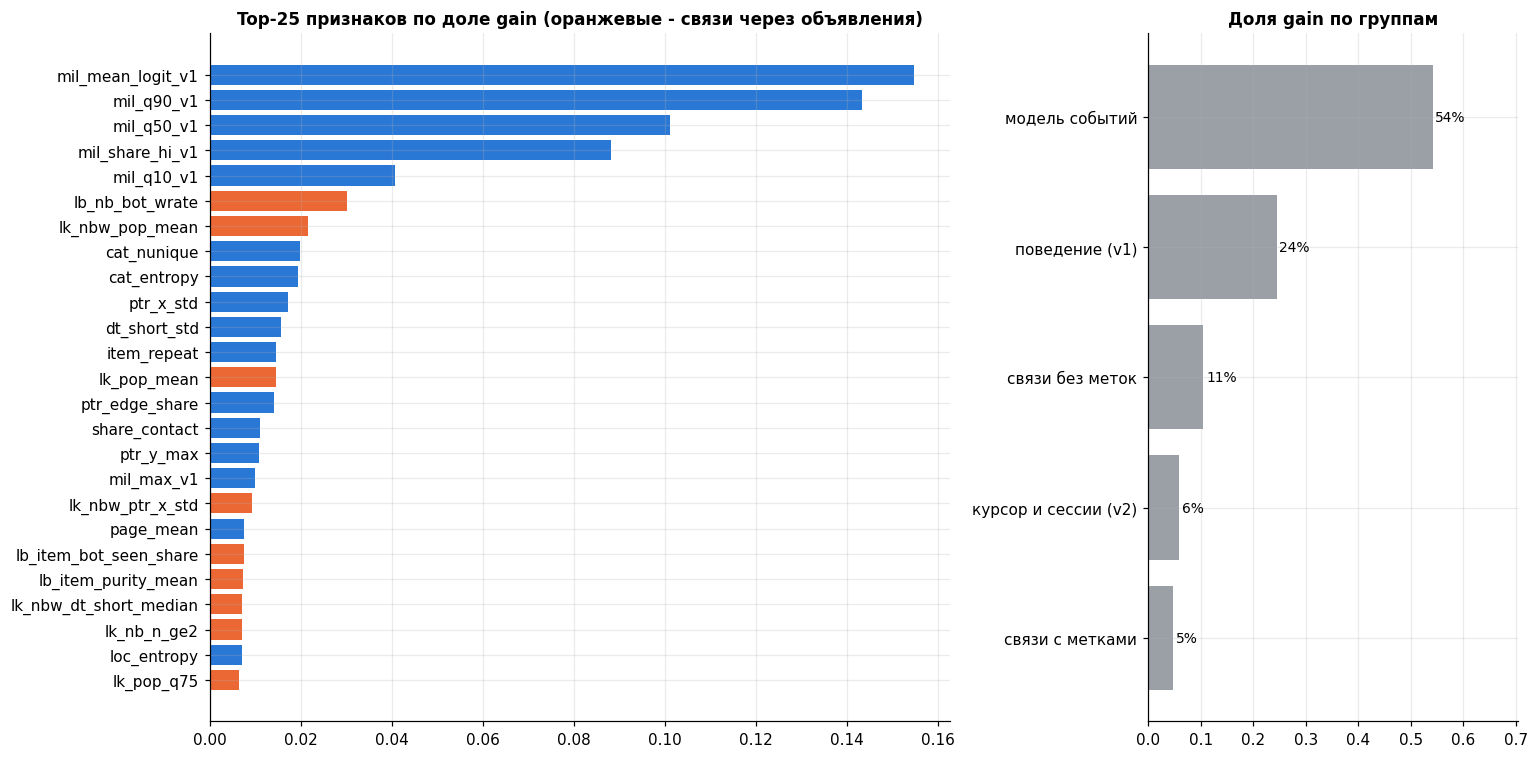

максимальная доля одного признака: 0.155 (mil_mean_logit_v1)
Полное время работы ноутбука: 35.4 мин


In [29]:
Xf = assemble(Xtr, mil_tr, ('v1',), lab_tr)
m = lgb.LGBMClassifier(**LGB_A3, random_state=SEED).fit(Xf, y)
imp = pd.Series(m.booster_.feature_importance('gain'), Xf.columns)
imp = imp / imp.sum()


def group_of(c):
    if c.startswith('lb_'):
        return 'связи с метками'
    if c.startswith('lk_'):
        return 'связи без меток'
    if c.startswith('mil_'):
        return 'модель событий'
    if c in EXTRA:
        return 'курсор и сессии (v2)'
    return 'поведение (v1)'


fig, ax = plt.subplots(1, 2, figsize=(14, 7), gridspec_kw={'width_ratios': [2, 1]})
top = imp.sort_values().tail(25)
ax[0].barh(top.index, top.values, color=['#eb6834' if c.startswith(('lk_', 'lb_')) else '#2a78d6' for c in top.index])
ax[0].set_title('Top-25 признаков по доле gain (оранжевые - связи через объявления)')
grp = imp.groupby(imp.index.map(group_of)).sum().sort_values()
ax[1].barh(grp.index, grp.values, color='#9aa0a6')
for j, v in enumerate(grp.values):
    ax[1].text(v + 0.005, j, f'{v:.0%}', va='center', fontsize=9)
ax[1].set_xlim(0, grp.max() * 1.3); ax[1].set_title('Доля gain по группам')
plt.tight_layout(); plt.show()
print('максимальная доля одного признака:', round(imp.max(), 3), f'({imp.idxmax()})')
print(f'Полное время работы ноутбука: {(time.time() - T0) / 60:.1f} мин')

Признаки связей вместе забирают около 16% gain (11% без меток, 5% с метками), самый сильный из них -
`lb_nb_bot_wrate`, 3%. Основа модели прежняя: оценки модели событий (54%) и поведенческие признаки (30%).
Связи уточняют поведенческую оценку, а не заменяют её. Отсюда можно ожидать, что при исчезновении сигнала связей
модель потеряет часть точности, но не весь результат. Прямо это не проверялось.

## 11. Что пробовали в v3

Варианты признаков связей сначала отсеивались на быстрой схеме: один LightGBM A с параметрами v2, 2 сида,
признаки куки v2 без модели событий, те же фолды FWD и LDO. Шум такой схемы около 0.01, поэтому она
годится только для грубого отбора. Итоговое сравнение - в разделе 9.

| вариант | FWD mean | LDO P@R | решение |
|---|---|---|---|
| признаки куки v2 без модели событий | 0.773 | 0.803 | точка отсчёта |
| + связи без меток (16 признаков) | 0.859 | 0.876 | взяли |
| средние по 12 признакам соседей вместо 6 | 0.854 | 0.862 | не взяли: избыточны, хуже на LDO |
| + 13 признаков с метками, без задержки меток | 0.870 | 0.868 | не взяли: LDO хуже |
| + 4 признака с метками, без задержки | 0.864 | 0.868 | не взяли: LDO хуже |
| + 13 признаков с метками, задержка 0-5 дней | 0.856 | 0.873 | не взяли |
| + 4 признака с метками, задержка 0-5 дней | 0.869 | 0.879 | взяли |
| параметры v3 для LightGBM (lr 0.015, 11 листьев, colsample 0.5) | 0.858 | 0.867 | в пределах шума, взяли ради устойчивости |

Набор из 13 признаков с метками включал также долю объявлений, виденных известными людьми, долю известных ботов
на объявление (на 100 ботов), максимальную чистоту объявления, число соседей-ботов и соседей-людей, долю ботов
среди соседей без веса, максимальный Жаккар с человеком и отношение Жаккаров, число соседей-ботов с 2+ общими
объявлениями. Они дублируют друг друга и оставленную четвёрку.

Задержка меток понадобилась из-за разной "свежести" истории. Без неё обучающая кука всегда видит метки
предыдущего дня, а кука теста - метки, которым 1-7 дней. Модель привыкает к более свежему сигналу, чем получит
на тесте, и на LDO это видно как падение.

В полном цикле (раздел 9) признаки с метками поверх связей без меток дают +0.007 на FWD и -0.001 на LDO,
то есть в пределах шума. Почти весь прирост v3 даёт блок без меток.

Два решения v3 сделаны в обход правила из раздела 8, и это стоит назвать прямо. Признаки с метками не улучшают
LDO, а новые параметры бустингов в быстрой проверке были в пределах шума. Оба оставлены осознанно: признаки
с метками помогают на FWD, который ближе к устройству test (обучение только на прошлом), а параметры с меньшей
долей признаков на дерево снижают зависимость от отдельных признаков связей. Если строго следовать правилу,
их нужно убрать; ожидаемая разница - в пределах шума.

## 12. Выводы и ограничения

v3 даёт самый большой прирост среди версий: P@R на forward-CV 0.868 против 0.775 у v2 (+0.093), на LDO 0.879
против 0.829 (+0.050). По парному бутстрапу v3 лучше v2 с вероятностью 1.0, 90% интервал разницы на LDO
от +0.03 до +0.09. Прирост есть во всех трёх фолдах forward-CV и у каждой из пяти моделей по отдельности,
то есть он идёт от признаков, а не от модели. При recall 0.7 ложных срабатываний на треть меньше: 87 против 130.
На платформе v3 получила 0.8997 (константа - 0.094).

Главный новый сигнал - пересечения кук по объявлениям. Он не зависит от поведения: боты разных кук обходят
один каталог. Сильнее всего работают признаки без меток - популярность объявлений среди других кук и поведение
кук-соседей. Признаки с известными ботами добавляют немного и в пределах шума.

Ограничения:

- Признаки связей зависят от накопленной истории. В первые дни train истории мало, на test её больше, чем в любом
  фолде. Нормировка на число кук тех же дней это сглаживает, но не убирает. Результат на платформе (0.8997)
  действительно выше CV (0.87-0.88), но разница укладывается и в обычный шум метрики.
- Признаки без меток используют куки test того же и прошлых дней. Это допустимо (события произошли до конца окна,
  меток нет), но в проде их нужно считать по всему трафику до момента скоринга: потоковым счётчиком просмотров
  по объявлениям и графом кук за последние дни.
- Признаки с метками на test опираются на все 14 дней разметки, больше, чем в валидации. Задержка меток снижает
  этот риск, но не устраняет полностью.
- Сигнал связей уязвим к адаптации: сервис может рандомизировать список объявлений или разнести его по разным
  кукам. Поведенческая часть модели при этом остаётся.
- Мобильные боты по-прежнему находятся хуже десктопных, recall около 0.5.
- P@R на пороге recall 0.7 шумит на 0.02-0.03. Результат на тесте может отличаться от CV на эту величину.